In [ ]:
from pathlib import Path

DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [2]:
dicom_files = list(DATA_ROOT.rglob("*.dcm"))

print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())
print("Mapping file found:", MAPPING_FILE.exists())

assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


In [3]:
# Import required libraries

from collections import Counter
import random
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.v2 as T
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    auc,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models import DenseNet121_Weights, densenet121

# A. Define the task and inspect the data

**Input:** The model receives a frontal chest X-ray image stored in DICOM format.

**Output:** The model predicts a binary label `1` or `0`:  
    * `1` indicates annotated lung opacity consistent with possible pneumonia
    * `0` indicates no such annotated opacity. This does not necessarily mean that the radiograph is clinically normal

**Clinical question:** Can the model identify chest X-rays showing lung opacity consistent with possible pneumonia?

**Limitation**: These labels are expert image annotations of possible pneumonia rather than confirmed clinical diagnoses. Therefore, the reported performance metrics measure how well the model predicts this annotation-derived proxy target. They must not be interpreted as diagnostic accuracy for clinically confirmed pneumonia.

In [4]:
# Task A - Part 1 (Load the label file and supplied RSNA-to-NIH mapping file)

labels = pd.read_csv(LABEL_FILE)
mapping = pd.read_csv(MAPPING_FILE)

print("Label table shape:", labels.shape)
print("Label columns:", labels.columns.tolist())
print("Mapping table shape:", mapping.shape)
print("Mapping columns:", mapping.columns.tolist())

Label table shape: (28989, 9)
Label columns: ['patientId', 'x', 'y', 'width', 'height', 'Target', 'StudyInstanceUID', 'SeriesInstanceUID', 'SOPInstanceUID']
Mapping table shape: (25684, 3)
Mapping columns: ['patientId', 'nih_patient_id', 'nih_image_id']


In [5]:
# Task A - Validate the annotation and mapping tables

def is_missing(series):
    blank = series.astype("string").str.strip().eq("").fillna(False)
    return series.isna() | blank


box_columns = ["x", "y", "width", "height"]
uid_columns = ["StudyInstanceUID", "SeriesInstanceUID", "SOPInstanceUID"]
mapping_columns = ["patientId", "nih_patient_id", "nih_image_id"]
required_label_columns = ["patientId", "Target", *box_columns, *uid_columns]

assert set(required_label_columns).issubset(labels.columns), (
    f"Missing label columns: {set(required_label_columns) - set(labels.columns)}"
)
assert set(mapping_columns).issubset(mapping.columns), (
    f"Missing mapping columns: {set(mapping_columns) - set(mapping.columns)}"
)

assert not labels[["patientId", "Target", *uid_columns]].apply(
    is_missing
).any().any(), "Required label values are missing"
assert labels["Target"].isin([0, 1]).all(), "Targets must be binary"
assert labels.groupby("patientId")["Target"].nunique().le(1).all(), (
    "An examination contains conflicting targets"
)

boxes = labels[box_columns].apply(pd.to_numeric, errors="coerce")
positive_rows = labels["Target"].eq(1)
negative_rows = labels["Target"].eq(0)

assert boxes.loc[positive_rows, ["x", "y"]].ge(0).all().all(), (
    "Positive rows contain invalid box coordinates"
)
assert boxes.loc[positive_rows, ["width", "height"]].gt(0).all().all(), (
    "Positive rows contain invalid box dimensions"
)
assert labels.loc[negative_rows, box_columns].apply(is_missing).all().all(), (
    "Negative rows contain bounding-box values"
)

for column in uid_columns:
    assert labels.groupby("patientId")[column].nunique().eq(1).all(), (
        f"Examinations contain conflicting {column} values"
    )

assert not mapping[mapping_columns].apply(is_missing).any().any(), (
    "Required mapping values are missing"
)
assert mapping["patientId"].is_unique, "Mapping examination IDs must be unique"
assert mapping["nih_image_id"].is_unique, "NIH image IDs must be unique"
assert set(labels["patientId"]) == set(mapping["patientId"]), (
    "The label and mapping tables contain different examinations"
)

rows_per_exam = labels.groupby("patientId").size()

validation_summary = pd.Series({
    "Rows in annotation table": len(labels),
    "Unique examination IDs (patientId) in annotation table": labels["patientId"].nunique(),
    "Examinations with multiple rows in annotation table": int(rows_per_exam.gt(1).sum()),
    "Rows in RSNA-to-NIH mapping table": len(mapping),
    "Unique source patients (nih_patient_id) in mapping table": mapping["nih_patient_id"].nunique(),
    "Exact duplicate annotation rows": int(labels.duplicated().sum()),
    "Exact duplicate mapping rows": int(mapping.duplicated().sum()),
})

print(validation_summary.to_string())
print("\nAll source-table validation checks passed")

Rows in annotation table                                    28989
Unique examination IDs (patientId) in annotation table      25684
Examinations with multiple rows in annotation table          3178
Rows in RSNA-to-NIH mapping table                           25684
Unique source patients (nih_patient_id) in mapping table    11171
Exact duplicate annotation rows                                 0
Exact duplicate mapping rows                                    0

All source-table validation checks passed


### Source-table structure

**Note:** despite its name, `patientId` is an **examination identifier**, not a verified person-level identifier. It appears in both tables and is used to link the annotation data to the RSNA-to-NIH mapping.

- **Annotation table:** `patientId` (examination) --> `Target`.
    * One examination can have multiple rows because a positive examination can have multiple annotated boxes. These rows are collapsed to one binary label per examination.

- **RSNA-to-NIH mapping table:** `patientId` (examination) --> `nih_patient_id` (source patient).
    * Each examination appears once, while one source patient can have multiple examinations. Therefore, `nih_patient_id` is used for patient-level splitting.

In [6]:
# Task A - Collapse annotations and join the source patient identifiers

exam_labels = labels.groupby("patientId", as_index=False).agg(
    Target=("Target", "max"),
    StudyInstanceUID=("StudyInstanceUID", "first"),
    SeriesInstanceUID=("SeriesInstanceUID", "first"),
    SOPInstanceUID=("SOPInstanceUID", "first"),
)

examinations = exam_labels.merge(
    mapping[mapping_columns],
    on="patientId",
    how="inner",
    validate="one_to_one",
)

assert len(examinations) == labels["patientId"].nunique()
assert examinations["patientId"].is_unique

print("Examinations after grouping and joining:", len(examinations))
print("Unique source patients:", examinations["nih_patient_id"].nunique())
print("Columns:", examinations.columns.tolist())

Examinations after grouping and joining: 25684
Unique source patients: 11171
Columns: ['patientId', 'Target', 'StudyInstanceUID', 'SeriesInstanceUID', 'SOPInstanceUID', 'nih_patient_id', 'nih_image_id']


In [7]:
# Task A - Part 2 (Report the class counts and class proportions)

class_counts = examinations["Target"].value_counts().reindex([0, 1], fill_value=0)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Proportion": class_counts / len(examinations),
})
class_summary.index = ["Negative (0)", "Positive (1)"]

print(class_summary.round(4))

              Count  Proportion
Negative (0)  20025      0.7797
Positive (1)   5659      0.2203


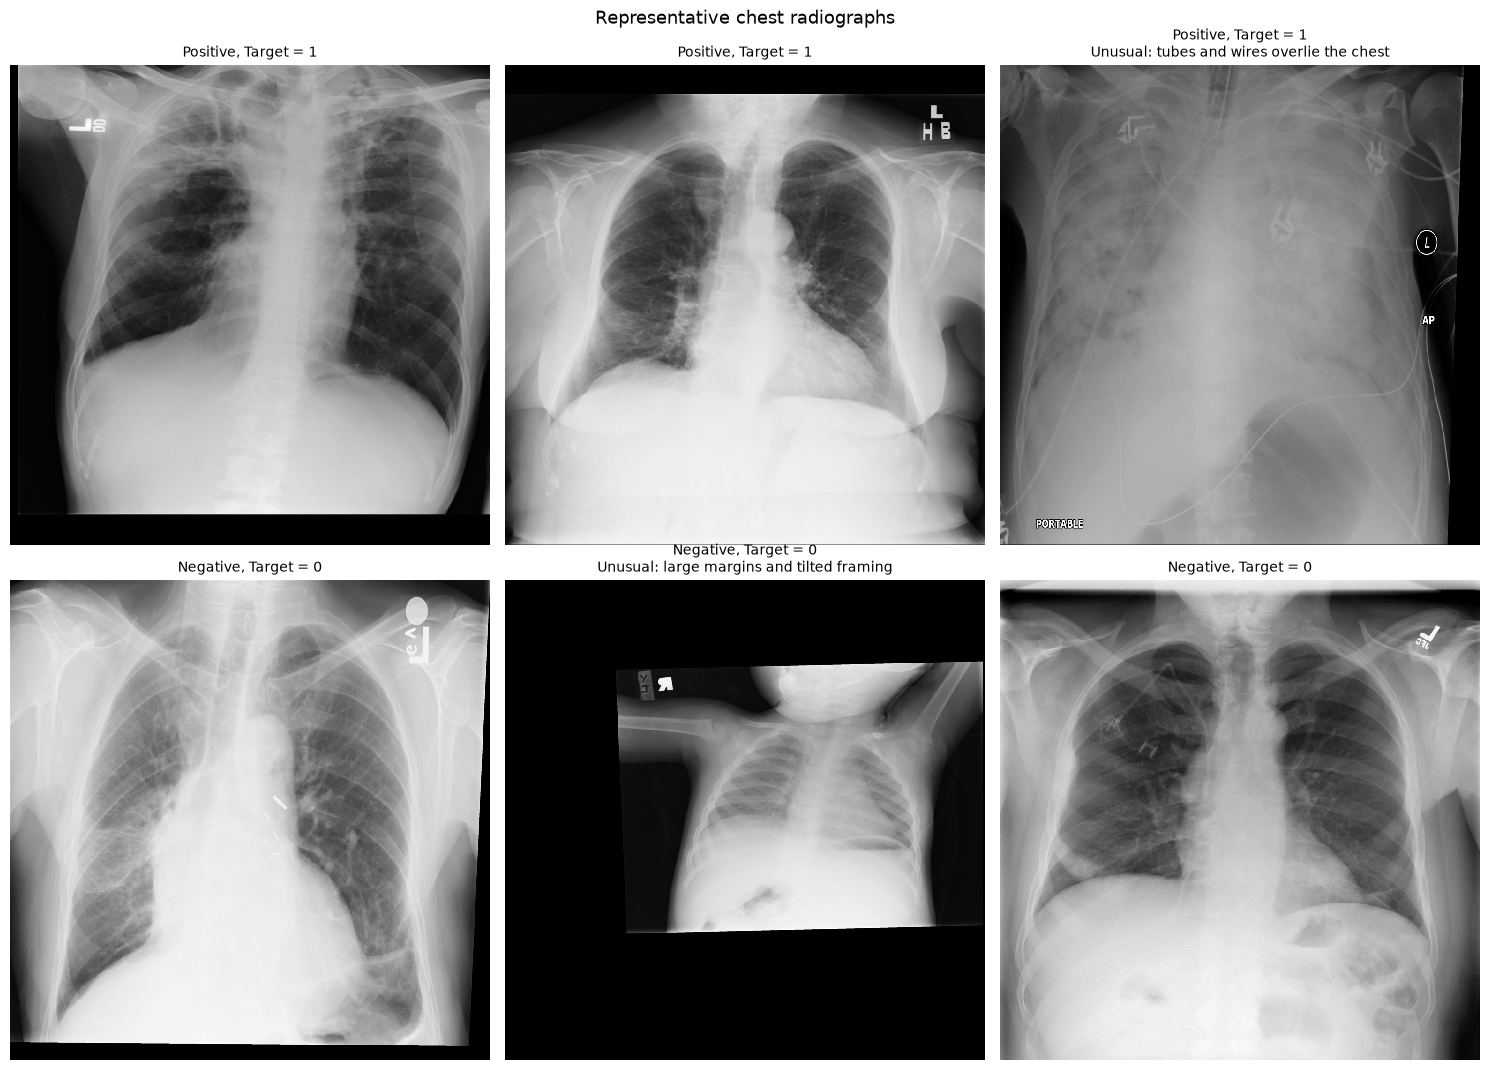

In [8]:
# Task A - Part 3 (Display six positive and negative examples, including unusual cases)

example_specs = [
    ("1.2.276.0.7230010.3.1.4.8323329.15110.1517874383.658635", ""),
    ("1.2.276.0.7230010.3.1.4.8323329.11413.1517874358.315902", ""),
    (
        "1.2.276.0.7230010.3.1.4.8323329.19899.1517874420.602906",
        "Unusual: tubes and wires overlie the chest",
    ),
    ("1.2.276.0.7230010.3.1.4.8323329.7298.1517874330.828015", ""),
    (
        "1.2.276.0.7230010.3.1.4.8323329.8216.1517874336.165289",
        "Unusual: large margins and tilted framing",
    ),
    ("1.2.276.0.7230010.3.1.4.8323329.17678.1517874405.595206", ""),
]

selected_uids = [uid for uid, _ in example_specs]
selected_notes = [note for _, note in example_specs]

path_by_uid = {path.stem: path for path in dicom_files}

assert len(path_by_uid) == len(dicom_files), "Duplicate DICOM filenames found"
assert set(examinations["SOPInstanceUID"]) == set(path_by_uid), (
    "The examination table and DICOM files do not match"
)

exam_lookup = examinations.set_index("SOPInstanceUID", drop=False)
selected_examples = exam_lookup.loc[selected_uids].copy()
selected_examples["Note"] = selected_notes

assert selected_examples["Target"].tolist() == [1, 1, 1, 0, 0, 0], (
    "The selected examples do not contain three positives followed by three negatives"
)

fig, axes = plt.subplots(2, 3, figsize=(15, 11))

for position, (_, record) in enumerate(selected_examples.iterrows()):
    uid = record["SOPInstanceUID"]
    dicom = pydicom.dcmread(path_by_uid[uid])
    pixels = dicom.pixel_array

    assert str(dicom.SOPInstanceUID) == uid
    assert pixels.ndim == 2, "Expected a grayscale image"

    photometric = str(dicom.PhotometricInterpretation)
    assert photometric in {"MONOCHROME1", "MONOCHROME2"}

    row, column = divmod(position, 3)
    target = int(record["Target"])
    class_name = "Positive" if target == 1 else "Negative"
    title = f"{class_name}, Target = {target}"

    if record["Note"]:
        title += f"\n{record['Note']}"

    axes[row, column].imshow(
        pixels,
        cmap="gray_r" if photometric == "MONOCHROME1" else "gray",
        interpolation="nearest",
    )
    axes[row, column].set_title(title, fontsize=10)
    axes[row, column].axis("off")

fig.suptitle("Representative chest radiographs", fontsize=13)
fig.tight_layout()
plt.show()

Scanned 5,000 of 25,684 images
Scanned 10,000 of 25,684 images
Scanned 15,000 of 25,684 images
Scanned 20,000 of 25,684 images
Scanned 25,000 of 25,684 images


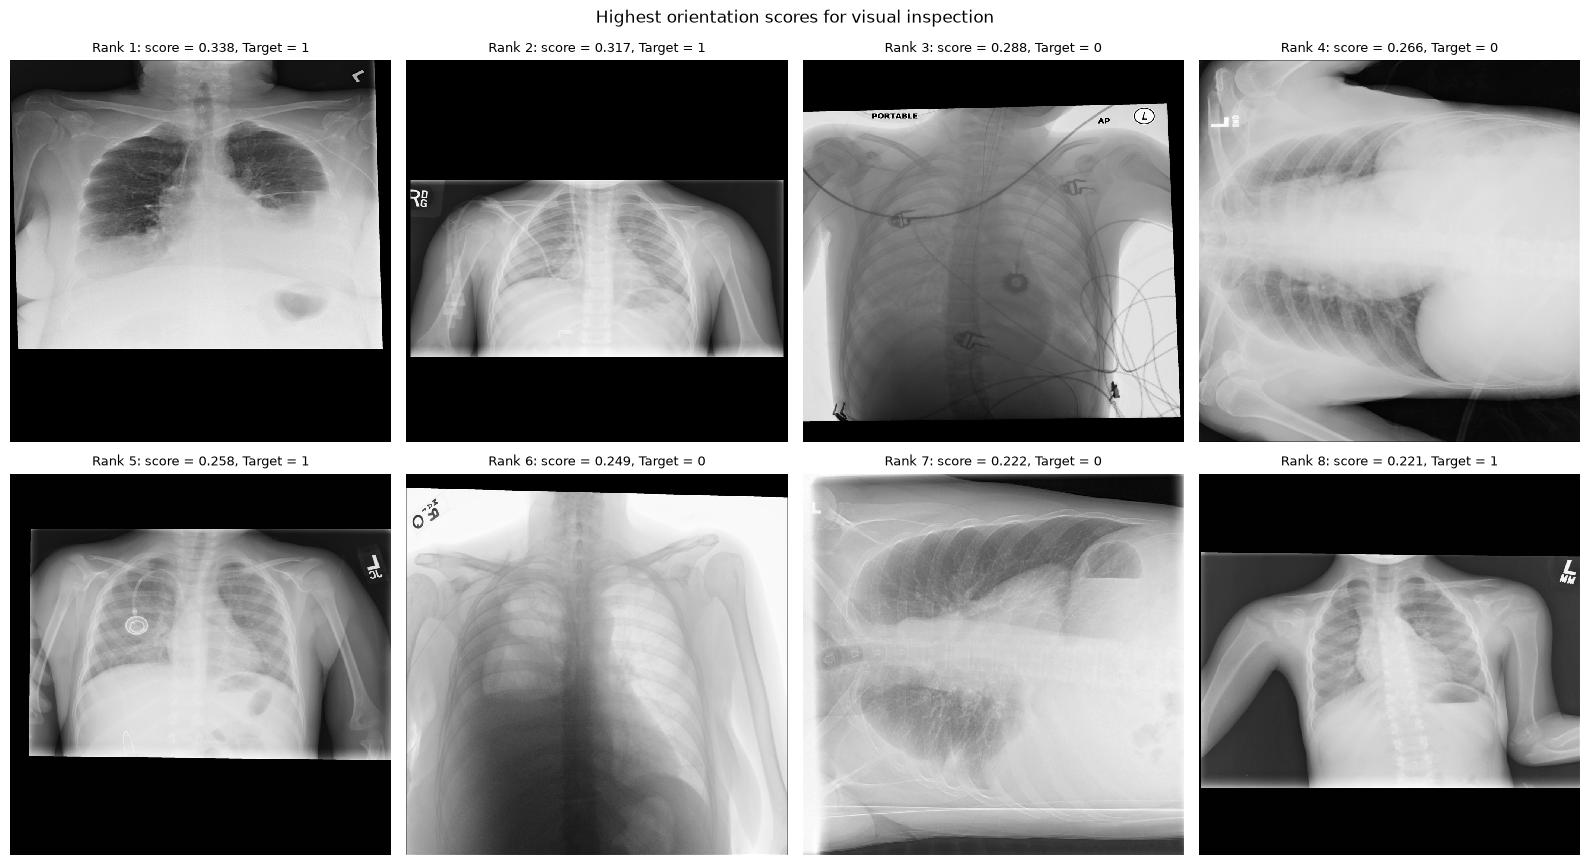

                                         SOPInstanceUID  Orientation score  Target
 1.2.276.0.7230010.3.1.4.8323329.2633.1517874297.628507           0.338448       1
 1.2.276.0.7230010.3.1.4.8323329.2111.1517874294.722125           0.317005       1
1.2.276.0.7230010.3.1.4.8323329.20071.1517874421.505775           0.287836       0
1.2.276.0.7230010.3.1.4.8323329.17151.1517874402.540026           0.266464       0
 1.2.276.0.7230010.3.1.4.8323329.20840.1517874430.72161           0.258329       1
 1.2.276.0.7230010.3.1.4.8323329.2094.1517874294.634415           0.248738       0
1.2.276.0.7230010.3.1.4.8323329.13937.1517874375.610682           0.221720       0
   1.2.276.0.7230010.3.1.4.8323329.28820.1517874487.812           0.221290       1


In [9]:
# Data quality - scan for 90-degree rotations and display the top candidates

N_CANDIDATES = 8


def orientation_score(path):
    """Return a screening score for horizontal rather than vertical structure"""

    dicom = pydicom.dcmread(path)
    pixels = dicom.pixel_array.astype(np.float32)

    if str(dicom.PhotometricInterpretation) == "MONOCHROME1":
        pixels = pixels.max() - pixels

    small = pixels[::4, ::4]
    value_range = np.ptp(small)

    if value_range > 0:
        small = (small - small.min()) / value_range

    def centre_contrast(profile):
        third = len(profile) // 3
        centre = profile[third:2 * third].mean()
        outer = np.concatenate([profile[:third], profile[2 * third:]]).mean()
        return centre - outer

    row_contrast = centre_contrast(small.mean(axis=1))
    column_contrast = centre_contrast(small.mean(axis=0))

    return row_contrast - column_contrast


orientation_scores = []

for index, uid in enumerate(examinations["SOPInstanceUID"], start=1):
    orientation_scores.append({
        "SOPInstanceUID": uid,
        "Orientation score": orientation_score(path_by_uid[uid]),
    })

    if index % 5000 == 0:
        print(f"Scanned {index:,} of {len(examinations):,} images")

orientation_results = pd.DataFrame(orientation_scores).merge(
    examinations[["SOPInstanceUID", "Target"]],
    on="SOPInstanceUID",
    validate="one_to_one",
)

orientation_candidates = orientation_results.nlargest(
    N_CANDIDATES,
    "Orientation score",
).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for rank, (ax, candidate) in enumerate(
    zip(axes.ravel(), orientation_candidates.itertuples()),
    start=1,
):
    dicom = pydicom.dcmread(path_by_uid[candidate.SOPInstanceUID])
    photometric = str(dicom.PhotometricInterpretation)

    ax.imshow(
        dicom.pixel_array,
        cmap="gray_r" if photometric == "MONOCHROME1" else "gray",
        interpolation="nearest",
    )
    ax.set_title(
        f"Rank {rank}: score = {candidate._2:.3f}, Target = {candidate.Target}",
        fontsize=9,
    )
    ax.axis("off")

fig.suptitle(
    "Highest orientation scores for visual inspection",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print(orientation_candidates.to_string(index=False))

### Orientation check

After visual inspection of the eight displayed candidates, I identified two sideways images at ranks 4 and 7. The other six candidates were upright. The score was used only to prioritize images for visual review and did not determine whether an image was rotated.

Both sideways images were retained because this check was intended to identify whether unusual orientations exist in the dataset, not to exclude such cases.

In [10]:
# Task A - Part 4 (Check image size, photometric interpretation and projection)

image_sizes = Counter()
photometric_interpretations = Counter()
view_positions = Counter()

for path in dicom_files:
    header = pydicom.dcmread(path, stop_before_pixels=True)

    image_sizes[(int(header.Rows), int(header.Columns))] += 1
    photometric_interpretations[
        str(getattr(header, "PhotometricInterpretation", "Missing"))
    ] += 1
    view_positions[str(getattr(header, "ViewPosition", "Missing"))] += 1

assert set(photometric_interpretations).issubset(
    {"MONOCHROME1", "MONOCHROME2"}
), "Unsupported photometric interpretation found"

metadata_summary = []

for (rows, columns), count in image_sizes.items():
    metadata_summary.append({
        "Field": "Image size",
        "Value": f"{rows} × {columns}",
        "Count": count,
    })

for value, count in photometric_interpretations.items():
    metadata_summary.append({
        "Field": "Photometric interpretation",
        "Value": value,
        "Count": count,
    })

for value, count in view_positions.items():
    metadata_summary.append({
        "Field": "View position",
        "Value": value,
        "Count": count,
    })

print(pd.DataFrame(metadata_summary).to_string(index=False))

                     Field       Value  Count
                Image size 1024 × 1024  25684
Photometric interpretation MONOCHROME2  25684
             View position          AP  11705
             View position          PA  13979


In [11]:
# Task B - Part 1 (Create patient-grouped training, validation and test splits)

SPLIT_SEED = 42

# A source patient is positive for stratification if any examination is positive
patients = examinations.groupby("nih_patient_id", as_index=False).agg(
    patient_label=("Target", "max"),
)

train_patients, remaining_patients = train_test_split(
    patients,
    test_size=0.30,
    stratify=patients["patient_label"],
    random_state=SPLIT_SEED,
)

validation_patients, test_patients = train_test_split(
    remaining_patients,
    test_size=0.50,
    stratify=remaining_patients["patient_label"],
    random_state=SPLIT_SEED,
)

patient_assignments = pd.concat(
    [
        train_patients.assign(split="train"),
        validation_patients.assign(split="validation"),
        test_patients.assign(split="test"),
    ],
    ignore_index=True,
)[["nih_patient_id", "split"]]

# Remove a previous split assignment if this cell is rerun
examinations = examinations.drop(
    columns=["split", "split_x", "split_y"],
    errors="ignore",
)

examinations = examinations.merge(
    patient_assignments,
    on="nih_patient_id",
    how="left",
    validate="many_to_one",
)

assert examinations["split"].notna().all()

print("Patients per split:")
print(
    examinations.groupby("split")["nih_patient_id"]
    .nunique()
    .reindex(["train", "validation", "test"])
    .rename_axis(None)
    .to_string()
)

print("\nExaminations per split:")
print(
    examinations["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
    .rename_axis(None)
    .to_string()
)

Patients per split:
train         7819
validation    1676
test          1676

Examinations per split:
train         17885
validation     4045
test           3754


### Task B - Part 2 - Test-set policy

The training split is used to fit model parameters. The validation split is used to select hyperparameters, choose between weighted and unweighted loss, select CNN checkpoints, and choose operating thresholds. The test split is not used for any of these decisions.

The test split is evaluated only after all training and model-selection decisions are fixed. At that point, the selected simple baseline and the three independently trained CNN seed runs are evaluated on the same reserved test examinations. All subsequent test-set analyses use the already selected models and thresholds without further model selection or re-tuning.

In [12]:
# Task B - Part 3 (Use assertions to demonstrate that the patient sets are disjoint)

train_ids = set(
    examinations.loc[examinations["split"] == "train", "nih_patient_id"]
)
validation_ids = set(
    examinations.loc[examinations["split"] == "validation", "nih_patient_id"]
)
test_ids = set(
    examinations.loc[examinations["split"] == "test", "nih_patient_id"]
)

assert train_ids.isdisjoint(validation_ids), (
    "Patients appear in both training and validation"
)
assert train_ids.isdisjoint(test_ids), (
    "Patients appear in both training and test"
)
assert validation_ids.isdisjoint(test_ids), (
    "Patients appear in both validation and test"
)
assert train_ids | validation_ids | test_ids == set(
    examinations["nih_patient_id"]
), "Not every patient was assigned exactly once"

print("All patient sets are disjoint")
print("Training patients:", len(train_ids))
print("Validation patients:", len(validation_ids))
print("Test patients:", len(test_ids))

All patient sets are disjoint
Training patients: 7819
Validation patients: 1676
Test patients: 1676


In [13]:
# Task B - Part 4 (Report the size and positive-class proportion of every split)

split_summary = examinations.groupby("split").agg(
    Patients=("nih_patient_id", "nunique"),
    Examinations=("patientId", "size"),
    Positives=("Target", "sum"),
)

split_summary["Positive proportion"] = (
    split_summary["Positives"] / split_summary["Examinations"]
)

split_summary = (
    split_summary
    .reindex(["train", "validation", "test"])
    .rename_axis(None)
)

print(split_summary.round(4))

print(
    "\nPositive proportion across all examinations:",
    round(examinations["Target"].mean(), 4),
)

            Patients  Examinations  Positives  Positive proportion
train           7819         17885       3975               0.2223
validation      1676          4045        922               0.2279
test            1676          3754        762               0.2030

Positive proportion across all examinations: 0.2203


In [14]:
# Task B - Part 5 (Investigate site and acquisition information that could create leakage)

SITE_FIELDS = [
    "Manufacturer",
    "ManufacturerModelName",
    "InstitutionName",
    "StationName",
]
ACQUISITION_FIELDS = ["ViewPosition", "PixelSpacing"]
HEADER_FIELDS = SITE_FIELDS + ACQUISITION_FIELDS


def read_header_field(header, field):
    value = getattr(header, field, None)

    if value is None or not str(value).strip():
        return "Missing"

    if field == "PixelSpacing":
        return tuple(round(float(item), 6) for item in value)

    return str(value)


training_examinations = examinations[
    examinations["split"] == "train"
].copy()

metadata_records = []

for uid in training_examinations["SOPInstanceUID"]:
    header = pydicom.dcmread(path_by_uid[uid], stop_before_pixels=True)
    record = {"SOPInstanceUID": uid}

    for field in HEADER_FIELDS:
        record[field] = read_header_field(header, field)

    metadata_records.append(record)

training_metadata = training_examinations.merge(
    pd.DataFrame(metadata_records),
    on="SOPInstanceUID",
    validate="one_to_one",
)

availability_rows = []

for field in HEADER_FIELDS:
    available = training_metadata.loc[
        training_metadata[field] != "Missing",
        field,
    ]

    availability_rows.append({
        "Field": field,
        "Missing values": int((training_metadata[field] == "Missing").sum()),
        "Distinct available values": available.nunique(),
    })

print(pd.DataFrame(availability_rows).to_string(index=False))

                Field  Missing values  Distinct available values
         Manufacturer           17885                          0
ManufacturerModelName           17885                          0
      InstitutionName           17885                          0
          StationName           17885                          0
         ViewPosition               0                          2
         PixelSpacing               0                         15


In [15]:
# Task B - Part 5 (Compare training-set positive rates across acquisition groups)

training_positive_rate = training_metadata["Target"].mean()

print(f"Training positive rate: {training_positive_rate:.4f}")

for field in ACQUISITION_FIELDS:
    group_summary = (
        training_metadata.groupby(field, dropna=False)
        .agg(
            Examinations=("Target", "size"),
            Positive_proportion=("Target", "mean"),
        )
        .sort_values("Examinations", ascending=False)
    )

    group_summary["Difference_from_training_proportion"] = (
        group_summary["Positive_proportion"] - training_positive_rate
    )

    print(f"\n{field}:")
    print(group_summary.round(4).to_string())

Training positive rate: 0.2223

ViewPosition:
              Examinations  Positive_proportion  Difference_from_training_proportion
ViewPosition                                                                        
PA                    9808               0.0926                              -0.1297
AP                    8077               0.3797                               0.1575

PixelSpacing:
                      Examinations  Positive_proportion  Difference_from_training_proportion
PixelSpacing                                                                                
(0.143, 0.143)                6092               0.0836                              -0.1387
(0.168, 0.168)                5932               0.3205                               0.0982
(0.139, 0.139)                3625               0.3117                               0.0895
(0.171, 0.171)                1339               0.2756                               0.0533
(0.194311, 0.194311)           850       

### Further leakage route: site and scanner confounding

Patient-level splitting prevents the same source patient from appearing across splits. However, the same hospitals or scanners could still appear in all splits. If site or scanner characteristics are associated with the target, the model could exploit acquisition-specific patterns rather than the intended clinical features.

To test this in a multi-site dataset, I would:
1. Compare positive proportions across sites/scanners.
2. Test whether site/scanner metadata alone can predict the target.
3. Evaluate the image model on a held-out site. A substantial performance drop would suggest reliance on site-specific information.

Grad-CAM could complement these tests by revealing attention to visible acquisition artefacts. It alone, however, cannot establish site/scanner leakage or prove that a highlighted feature caused the prediction.

In this dataset, direct site/scanner fields are missing from all 17,885 training examinations. However, available acquisition metadata such as `ViewPosition` and `PixelSpacing` are associated with the target. 37.97% of AP examinations are positive versus 9.26% of PA examinations, and the five most common pixel spacings have positive proportions from 6.82% to 32.05%.

These associations show that acquisition-related information could provide predictive signal, but they do not prove site/scanner leakage or that the CNN uses these variables as shortcuts. In Task G, I examine AP and PA separately to determine whether model performance differs by projection.

In [16]:
# Task C - Part 1 (Define DICOM scaling and evaluation preprocessing)
# Evaluation transform: scale -> resize -> repeat to 3 channels -> normalize

# Read the preprocessing values from the selected pretrained weights
PRETRAINED_WEIGHTS = DenseNet121_Weights.IMAGENET1K_V1
PRETRAINED_TRANSFORM = PRETRAINED_WEIGHTS.transforms()

IMAGE_SIZE = PRETRAINED_TRANSFORM.crop_size[0]
IMAGENET_MEAN = list(PRETRAINED_TRANSFORM.mean)
IMAGENET_STD = list(PRETRAINED_TRANSFORM.std)


def load_dicom_pixels(path):
    """Load one DICOM image and scale its stored values to [0, 1]"""

    dicom = pydicom.dcmread(path)

    assert str(dicom.PhotometricInterpretation) == "MONOCHROME2"
    assert int(dicom.PixelRepresentation) == 0, "Expected unsigned pixel data"

    pixels = dicom.pixel_array.astype(np.float32)
    maximum_stored_value = float(2 ** int(dicom.BitsStored) - 1)

    return np.clip(pixels / maximum_stored_value, 0.0, 1.0)


class ChestXrayDataset(Dataset):
    """Return one transformed image and its binary label"""

    def __init__(self, frame, path_by_uid, transform):
        self.uids = frame["SOPInstanceUID"].tolist()
        self.labels = frame["Target"].to_numpy(dtype=np.float32)
        self.path_by_uid = path_by_uid
        self.transform = transform

    def __len__(self):
        return len(self.uids)

    def __getitem__(self, index):
        uid = self.uids[index]
        pixels = load_dicom_pixels(self.path_by_uid[uid])

        image = torch.from_numpy(pixels).unsqueeze(0)
        image = self.transform(image)
        label = torch.tensor(self.labels[index], dtype=torch.float32)

        return image, label


# Resize the complete square radiograph instead of applying a centre crop
evaluation_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    T.Lambda(lambda image: image.repeat(3, 1, 1)),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

sample_frame = training_examinations.head(1)
sample_uid = sample_frame.iloc[0]["SOPInstanceUID"]
scaled_pixels = load_dicom_pixels(path_by_uid[sample_uid])

sample_dataset = ChestXrayDataset(
    sample_frame,
    path_by_uid,
    evaluation_transform,
)
sample_image, sample_label = sample_dataset[0]

print(f"Resized CNN input size: {IMAGE_SIZE} × {IMAGE_SIZE}")
print("ImageNet normalization mean:", IMAGENET_MEAN)
print("ImageNet normalization standard deviation:", IMAGENET_STD)
print(
    f"Scaled pixel range: {scaled_pixels.min():.3f} to "
    f"{scaled_pixels.max():.3f}"
)
print("CNN input tensor shape:", tuple(sample_image.shape))
print("CNN input tensor dtype:", sample_image.dtype)
print(
    f"Normalized CNN input range: {sample_image.min():.3f} to "
    f"{sample_image.max():.3f}"
)

Resized CNN input size: 224 × 224
ImageNet normalization mean: [0.485, 0.456, 0.406]
ImageNet normalization standard deviation: [0.229, 0.224, 0.225]
Scaled pixel range: 0.000 to 1.000
CNN input tensor shape: (3, 224, 224)
CNN input tensor dtype: torch.float32
Normalized CNN input range: -2.118 to 1.859


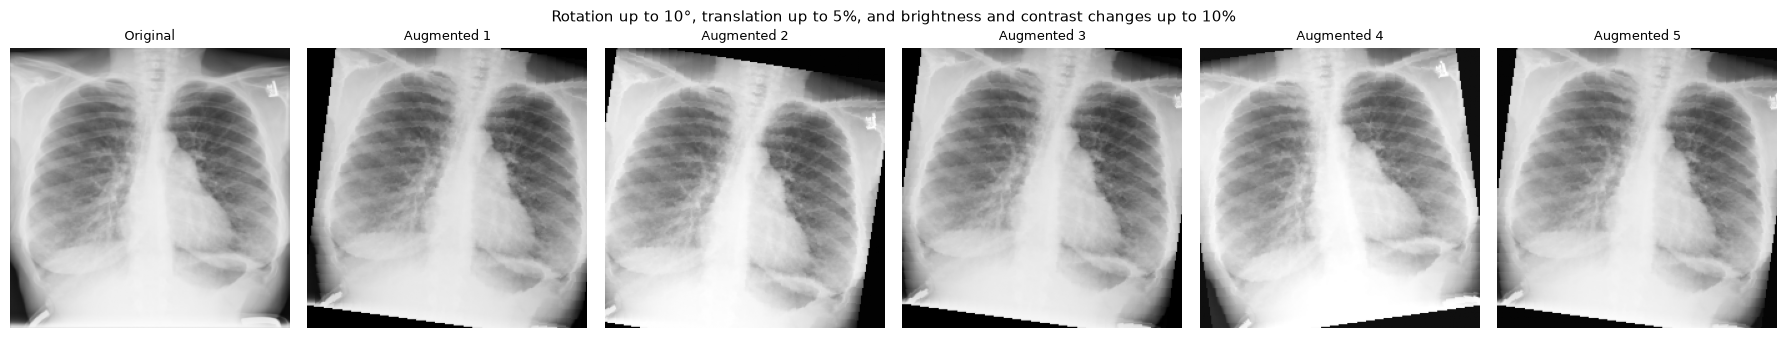

Training: scale → resize → augment → repeat channels → normalize
Evaluation: scale → resize → repeat channels → normalize


In [17]:
# Task C - Part 2 (Apply safe training-only augmentation and training preprocessing)
# Training transform: scale -> resize -> augment -> repeat to 3 channels -> normalize

AUGMENT_SEED = 42

training_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),

    # Keep positioning changes small enough to preserve plausible anatomy
    T.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        fill=0.0,
    ),

    # Apply mild intensity variation before normalization
    T.ColorJitter(
        brightness=0.1,
        contrast=0.1,
    ),

    T.Lambda(lambda image: image.repeat(3, 1, 1)),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def denormalize(tensor):
    """Reverse normalization for image display"""

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    return (tensor * std + mean).clamp(0, 1)[0]


panel_frame = training_examinations[
    training_examinations["Target"] == 1
].head(1)

original_image = ChestXrayDataset(
    panel_frame,
    path_by_uid,
    evaluation_transform,
)[0][0]

torch.manual_seed(AUGMENT_SEED)

augmented_dataset = ChestXrayDataset(
    panel_frame,
    path_by_uid,
    training_transform,
)
augmented_images = [
    augmented_dataset[0][0]
    for _ in range(5)
]

fig, axes = plt.subplots(1, 6, figsize=(18, 3.4))

axes[0].imshow(
    denormalize(original_image),
    cmap="gray",
    vmin=0,
    vmax=1,
)
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")

for index, image in enumerate(augmented_images, start=1):
    axes[index].imshow(
        denormalize(image),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[index].set_title(f"Augmented {index}", fontsize=9)
    axes[index].axis("off")

fig.suptitle(
    "Rotation up to 10°, translation up to 5%, "
    "and brightness and contrast changes up to 10%",
    fontsize=11,
)
fig.tight_layout()
plt.show()

print("Training: scale → resize → augment → repeat channels → normalize")
print("Evaluation: scale → resize → repeat channels → normalize")

### CNN input preprocessing

The original 1024 × 1024 grayscale DICOM images are scaled to [0, 1] and resized to 224 × 224. I use 224 × 224 because this is the standard image size used with the ImageNet-pretrained DenseNet121. The full radiograph is resized rather than cropped so that peripheral information is retained.

The single grayscale channel is repeated to three channels and normalized using the ImageNet mean and standard deviation. The final CNN input is a `float32` tensor with shape `(3, 224, 224)`.

- **Validation/test:** `scale -> resize -> repeat to 3 channels -> normalize`
- **Training:** `scale -> resize -> augment -> repeat to 3 channels -> normalize`

### Task C - Part 3 (Do not use transformations that change the clinical meaning or create implausible anatomy. Horizontal flipping of a chest radiograph requires an explicit justification if used.)

### Transformations deliberately excluded

**Retained:** rotation up to 10°, translation up to 5%, and brightness and contrast changes up to 10%. They are applied only to training images.

**Excluded:**

- **Horizontal flip:** I excluded it because it reverses left-right anatomy and any laterality markers in the image.

- **Vertical flip and 90-degree rotation:** I excluded both. Task A identified two sideways source images, but deliberately applying this acquisition error during training would make it much more common than the observed data supports.

- **Elastic and perspective distortion:** I excluded these because they alter anatomical shape and could change the appearance of an opacity.

- **Large brightness and contrast changes:** I limited brightness and contrast changes to 10% so the images vary slightly without making opacities look unrealistically faint or strong.

In [18]:
# Task C - Part 4 (Define the weighted-loss strategy for class imbalance)

training_labels = examinations.loc[
    examinations["split"] == "train",
    "Target",
]

training_negatives = int((training_labels == 0).sum())
training_positives = int((training_labels == 1).sum())

# Balance the total loss contribution of the two classes using training data only
POS_WEIGHT = training_negatives / training_positives

print("Training negatives:", training_negatives)
print("Training positives:", training_positives)
print(
    f"Positive-class weight: {training_negatives} / "
    f"{training_positives} = {POS_WEIGHT:.3f}"
)

Training negatives: 13910
Training positives: 3975
Positive-class weight: 13910 / 3975 = 3.499


In [19]:
# Task D - Part 1 (Report the majority-class baseline)
# Trivial baseline

# Select the majority class from the training split only
MAJORITY_CLASS = int(training_labels.mode().iloc[0])

print("Training majority class:", MAJORITY_CLASS)


def evaluate_predictions(y_true, y_pred, name):
    """Calculate confusion-matrix counts and classification metrics"""

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0

    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if precision + sensitivity
        else 0.0
    )

    return {
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
    }


validation_targets = examinations.loc[
    examinations["split"] == "validation",
    "Target",
].to_numpy()

majority_validation_predictions = np.full_like(
    validation_targets,
    MAJORITY_CLASS,
)

majority_validation = pd.DataFrame([
    evaluate_predictions(
        validation_targets,
        majority_validation_predictions,
        "Trivial baseline",
    )
]).set_index("Model")

print("\nValidation results:")
print(majority_validation.round(4).to_string())

Training majority class: 0

Validation results:
                    TN  FP   FN  TP  Accuracy  Sensitivity  Specificity  Precision   F1
Model                                                                                  
Trivial baseline  3123   0  922   0    0.7721          0.0          1.0        0.0  0.0


### Explanation

I used eight deterministic image-summary features: mean intensity, standard deviation, the 10th and 90th intensity percentiles, mean intensity in the central region, mean intensity near the image borders, the difference between central and border intensity, and the fraction of near-black pixels. These features summarize the image using a small set of intensity and location-based measurements, rather than learning detailed spatial patterns directly from the image as a CNN.

In [20]:
# Task D - Part 2 (Build a simple PyTorch baseline before using a pretrained CNN. One acceptable option
# is a logistic classifier (nn.Linear) using at least four image-summary features, such as the mean,
# standard deviation, selected intensity percentiles or coarse histogram bins. Clearly state the features used.)

FEATURE_NAMES = [
    "mean",
    "std",
    "p10",
    "p90",
    "centre_mean",
    "border_mean",
    "centre_minus_border",
    "dark_fraction",
]

BORDER_MARGIN = 0.08
DARK_THRESHOLD = 0.05


def summary_features(image):
    """Return eight scalar intensity summaries for a normalized grayscale image."""
    array = image.squeeze(0).numpy()
    height, width = array.shape

    quarter_height, quarter_width = height // 4, width // 4
    centre = array[
        quarter_height:3 * quarter_height,
        quarter_width:3 * quarter_width,
    ]

    margin_height = int(BORDER_MARGIN * height)
    margin_width = int(BORDER_MARGIN * width)

    border = np.concatenate([
        array[:margin_height, :].ravel(),
        array[-margin_height:, :].ravel(),
        array[:, :margin_width].ravel(),
        array[:, -margin_width:].ravel(),
    ])

    centre_mean = float(centre.mean())
    border_mean = float(border.mean())

    return np.array([
        float(array.mean()),
        float(array.std()),
        float(np.percentile(array, 10)),
        float(np.percentile(array, 90)),
        centre_mean,
        border_mean,
        centre_mean - border_mean,
        float((array < DARK_THRESHOLD).mean()),
    ], dtype=np.float32)


# Extract features from the resized image before any model normalization
feature_transform = T.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True)


def extract_features(frame, split_name):
    """Extract image-summary features and targets for one split."""
    X = np.zeros((len(frame), len(FEATURE_NAMES)), dtype=np.float32)
    y = frame["Target"].to_numpy().astype(np.float32)

    for i, uid in enumerate(frame["SOPInstanceUID"]):
        pixels = load_dicom_pixels(path_by_uid[uid])
        image = feature_transform(torch.from_numpy(pixels).unsqueeze(0))
        X[i] = summary_features(image)

        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i + 1} / {len(frame)}")

    return X, y


splits = {
    name: examinations[examinations["split"] == name]
    for name in ["train", "validation", "test"]
}

print("Extracting image-summary features:")
X_train, y_train = extract_features(splits["train"], "train")
X_val, y_val = extract_features(splits["validation"], "validation")
X_test, y_test = extract_features(splits["test"], "test")

np.savez(
    "baseline_features.npz",
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
)

print("\nFeature summary (training split):")
print(
    pd.DataFrame(X_train, columns=FEATURE_NAMES)
    .describe()
    .round(4)
    .to_string()
)

Extracting image-summary features:
  train: 5000 / 17885
  train: 10000 / 17885
  train: 15000 / 17885

Feature summary (training split):
             mean         std         p10         p90  centre_mean  border_mean  centre_minus_border  dark_fraction
count  17885.0000  17885.0000  17885.0000  17885.0000   17885.0000   17885.0000           17885.0000     17885.0000
mean       0.4900      0.2284      0.1568      0.7812       0.5114       0.3912               0.1201         0.0710
std        0.0847      0.0426      0.1194      0.0855       0.0866       0.1112               0.1130         0.0683
min        0.1263      0.0728      0.0000      0.2961       0.1301       0.0000              -0.4493         0.0000
25%        0.4335      0.1990      0.0551      0.7281       0.4437       0.3181               0.0431         0.0259
50%        0.4720      0.2341      0.1376      0.7980       0.4967       0.3805               0.1152         0.0570
75%        0.5376      0.2622      0.2345      0.8

In [21]:
# Task D - Part 3a (Definitions: feature standardization and the logistic model)

SIMPLE_BASELINE_SEED = 42
EPOCHS = 200
LEARNING_RATES = [0.01, 0.05, 0.1]


# Standardize features using statistics from the training split only
feature_mean = X_train.mean(axis=0)
feature_std = X_train.std(axis=0) + 1e-8


def standardize(X):
    return torch.from_numpy((X - feature_mean) / feature_std)


Xtr = standardize(X_train)
Xva = standardize(X_val)
Xte = standardize(X_test)
ytr = torch.from_numpy(y_train).unsqueeze(1)


def train_logistic(learning_rate, seed, weighted):
    """Train a logistic regression model using one nn.Linear layer."""
    torch.manual_seed(seed)

    model = nn.Linear(len(FEATURE_NAMES), 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([POS_WEIGHT]) if weighted else None
    )

    for _ in range(EPOCHS):
        optimizer.zero_grad()
        loss = criterion(model(Xtr), ytr)
        loss.backward()
        optimizer.step()

    return model


def probabilities(model, X):
    with torch.no_grad():
        return torch.sigmoid(model(X)).squeeze(1).numpy()


def select_logistic_on_validation(weighted, label):
    """Select the learning rate using validation ROC-AUC only."""
    print(f"\n{label}")
    print("  Selecting learning rate on the validation split:")

    candidates = []

    for lr in LEARNING_RATES:
        model = train_logistic(lr, SIMPLE_BASELINE_SEED, weighted)
        val_probs = probabilities(model, Xva)
        val_auc = roc_auc_score(y_val, val_probs)

        candidates.append((lr, val_auc, model, val_probs))

        print(
            f"    lr={lr:<5} "
            f"validation ROC-AUC = {val_auc:.4f}"
        )

    best_lr, best_val_auc, best_model, best_val_probs = max(
        candidates,
        key=lambda candidate: candidate[1],
    )

    print(
        f"  Selected lr={best_lr} "
        f"(validation ROC-AUC {best_val_auc:.4f})"
    )

    val_predictions = (best_val_probs >= 0.5).astype(int)

    row = evaluate_predictions(
        y_val,
        val_predictions,
        label,
    )
    row["ROC-AUC"] = best_val_auc

    return {
        "label": label,
        "weighted": weighted,
        "best_lr": best_lr,
        "best_val_auc": best_val_auc,
        "model": best_model,
        "validation_probabilities": best_val_probs,
        "validation_labels": y_val.copy(),
        "validation_metrics": row,
    }

In [22]:
# Task D - Part 3b (Training run 1 of 2: unweighted loss)

baseline_unweighted_result = select_logistic_on_validation(
    weighted=False,
    label="Simple baseline, unweighted loss",
)

model_unweighted = baseline_unweighted_result["model"]


Simple baseline, unweighted loss
  Selecting learning rate on the validation split:
    lr=0.01  validation ROC-AUC = 0.7477
    lr=0.05  validation ROC-AUC = 0.7593
    lr=0.1   validation ROC-AUC = 0.7586
  Selected lr=0.05 (validation ROC-AUC 0.7593)


In [23]:
# Task D - Part 3c (Training run 2 of 2: weighted loss, the configuration carried forward)

baseline_weighted_result = select_logistic_on_validation(
    weighted=True,
    label="Simple baseline, weighted loss",
)

model_weighted = baseline_weighted_result["model"]
baseline_model = model_weighted


Simple baseline, weighted loss
  Selecting learning rate on the validation split:
    lr=0.01  validation ROC-AUC = 0.7464
    lr=0.05  validation ROC-AUC = 0.7596
    lr=0.1   validation ROC-AUC = 0.7587
  Selected lr=0.05 (validation ROC-AUC 0.7596)


In [24]:
# Task C - Part 4a (Effect of the class-imbalance strategy on the simple baseline)
# Task D - Part 3d (Learned feature weights)

row_unweighted = baseline_unweighted_result["validation_metrics"]
row_weighted = baseline_weighted_result["validation_metrics"]

imbalance_comparison = pd.DataFrame(
    [row_unweighted, row_weighted]
).set_index("Model")

print(
    "Effect of the class-imbalance strategy "
    "on the simple baseline (validation set):"
)
print(imbalance_comparison.round(4).to_string())


weights = baseline_model.weight.detach().squeeze(0).numpy()

importance = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Weight": weights,
}).sort_values(
    "Weight",
    key=abs,
    ascending=False,
)

print("\nLearned weights, weighted model:")
print(importance.round(4).to_string(index=False))

Effect of the class-imbalance strategy on the simple baseline (validation set):
                                    TN    FP   FN   TP  Accuracy  Sensitivity  Specificity  Precision      F1  ROC-AUC
Model                                                                                                                 
Simple baseline, unweighted loss  3029    94  776  146    0.7849       0.1584       0.9699     0.6083  0.2513   0.7593
Simple baseline, weighted loss    2115  1008  252  670    0.6885       0.7267       0.6772     0.3993  0.5154   0.7596

Learned weights, weighted model:
            Feature  Weight
               mean -1.9945
        centre_mean  1.6735
                std -1.3727
                p10 -0.7229
        border_mean  0.6859
                p90  0.6456
      dark_fraction  0.1420
centre_minus_border -0.0685


### Explanation

I used ImageNet-pretrained DenseNet121 for the CNN baseline. Since the pretrained model expects three-channel RGB input, I repeated each grayscale chest radiograph across three channels rather than changing the first convolutional layer. This allows the original pretrained convolutional weights to be used unchanged.

I replaced DenseNet121's original 1000-class classification head with Linear(1024, 1) and used BCEWithLogitsLoss for binary classification. The model produces one logit, which is converted by a sigmoid into the probability of the positive class. The negative-class probability is its complement. Therefore, a single output is sufficient to predict both classes.


In [25]:
# Task E - Part 1 (Adapt an ImageNet-pretrained CNN for one-channel chest radiographs and binary
# classification. State exactly how you handled the channel mismatch and replaced the classification head.)

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device: {DEVICE}")


def build_model():
    """Return an ImageNet-pretrained DenseNet121 adapted for binary classification."""
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)

    n_features = model.classifier.in_features
    model.classifier = nn.Linear(n_features, 1)

    return model.to(DEVICE)


# Build a fresh model here to verify the adaptation
check_model = build_model()

print("Original head: Linear(1024, 1000)")
print(f"Replaced head: {check_model.classifier}")
print(f"Total parameters: {sum(p.numel() for p in check_model.parameters()):,}")


# Confirm that the model accepts the pipeline output and returns one logit per image
check_dataset = ChestXrayDataset(
    examinations.head(4),
    path_by_uid,
    evaluation_transform,
)
check_batch = torch.stack(
    [check_dataset[i][0] for i in range(4)]
).to(DEVICE)

check_model.eval()

with torch.no_grad():
    logits = check_model(check_batch)

print("\nVerification only: passing 4 images through the adapted CNN to check input and output shapes.")
print(f"\nInput batch shape: {tuple(check_batch.shape)}")
print(f"Output shape: {tuple(logits.shape)}")
print(f"Output values: {logits.squeeze(1).cpu().numpy().round(4)}")
print("\nOne logit per image; BCEWithLogitsLoss applies the sigmoid")

Device: cuda
Original head: Linear(1024, 1000)
Replaced head: Linear(in_features=1024, out_features=1, bias=True)
Total parameters: 6,954,881

Verification only: passing 4 images through the adapted CNN to check input and output shapes.

Input batch shape: (4, 3, 224, 224)
Output shape: (4, 1)
Output values: [0.0138 0.5619 0.5179 0.7979]

One logit per image; BCEWithLogitsLoss applies the sigmoid


### Explanation

Training was done in two stages:

1. **Fixed feature extraction:** I froze the pretrained DenseNet121 backbone, so its weights did not change, and trained only the new binary classification head for 5 epochs using a learning rate of `1e-3`. The frozen BatchNorm layers were also kept in evaluation mode so their running statistics did not change. The epoch with the highest validation ROC-AUC was kept.

2. **Fine-tuning:** Starting from the best model from Stage 1, I unfroze the final dense block (`denseblock4`) and final normalization layer (`norm5`) while keeping the earlier layers frozen. These layers and the classification head were trained together for 10 epochs using a lower learning rate of `1e-4`. Again, the epoch with the highest validation ROC-AUC was kept.

This allows the model to first learn the new classification task using the pretrained features, then adapt the highest-level CNN features to the chest X-ray task without changing the entire pretrained network.

In [26]:
# Task E - Part 2 (First train the CNN as a fixed feature extractor. Then fine-tune
# at least its final convolutional block.)

BATCH_SIZE = 32
FROZEN_EPOCHS = 5
FINETUNE_EPOCHS = 10
FROZEN_LR = 1e-3
FINETUNE_LR = 1e-4
NUM_WORKERS = 8

train_frame = examinations[
    examinations["split"] == "train"
].reset_index(drop=True)

val_frame = examinations[
    examinations["split"] == "validation"
].reset_index(drop=True)

test_frame = examinations[
    examinations["split"] == "test"
].reset_index(drop=True)


def make_loader(frame, transform, shuffle, seed=None):
    generator = (
        torch.Generator().manual_seed(seed)
        if seed is not None
        else None
    )

    return DataLoader(
        ChestXrayDataset(frame, path_by_uid, transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        generator=generator,
    )


def set_trainable(model, phase):
    """Set which parts of the model are trainable for each phase."""
    for parameter in model.parameters():
        parameter.requires_grad = False

    trainable_modules = [model.classifier]

    if phase == "finetune":
        trainable_modules.extend([
            model.features.denseblock4,
            model.features.norm5,
        ])

    for module in trainable_modules:
        for parameter in module.parameters():
            parameter.requires_grad = True

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def keep_frozen_batchnorm_in_eval(model):
    """
    Keep BatchNorm modules whose parameters are frozen in evaluation mode.

    This prevents their running statistics from changing during training,
    so the frozen backbone is genuinely fixed.
    """
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            parameters = list(module.parameters())

            if parameters and not any(
                parameter.requires_grad
                for parameter in parameters
            ):
                module.eval()


@torch.no_grad()
def predict(model, loader):
    """Return probabilities and labels for a complete split."""
    model.eval()

    probabilities_out = []
    labels = []

    for images, targets in loader:
        logits = model(
            images.to(DEVICE, non_blocking=True)
        ).squeeze(1)

        probabilities_out.append(
            torch.sigmoid(logits).cpu().numpy()
        )
        labels.append(targets.numpy())

    return (
        np.concatenate(probabilities_out),
        np.concatenate(labels),
    )


def run_phase(
    model,
    phase,
    epochs,
    learning_rate,
    weighted,
    seed,
    history,
    label,
):
    """Train one phase and restore its best validation-AUC weights."""
    n_trainable = set_trainable(model, phase)

    print(
        f"\n  {phase}: {n_trainable:,} trainable parameters, "
        f"lr={learning_rate}, {epochs} epochs"
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=(
            torch.tensor([POS_WEIGHT], device=DEVICE)
            if weighted
            else None
        )
    )

    optimizer = torch.optim.Adam(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
    )

    train_loader = make_loader(
        train_frame,
        training_transform,
        shuffle=True,
        seed=seed,
    )

    val_loader = make_loader(
        val_frame,
        evaluation_transform,
        shuffle=False,
    )

    best_auc = -1.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        started = time.time()

        model.train()

        # model.train() also switches frozen BatchNorm layers to training
        # mode, so restore frozen BatchNorm modules to evaluation mode.
        keep_frozen_batchnorm_in_eval(model)

        running_loss = 0.0
        n_seen = 0

        for images, targets in train_loader:
            images = images.to(
                DEVICE,
                non_blocking=True,
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True,
            ).unsqueeze(1)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            n_seen += images.size(0)

        train_loss = running_loss / n_seen

        val_probs, val_labels = predict(
            model,
            val_loader,
        )

        val_logits = torch.logit(
            torch.tensor(val_probs).clamp(
                1e-7,
                1 - 1e-7,
            )
        )

        val_loss = criterion(
            val_logits.unsqueeze(1).to(DEVICE),
            torch.tensor(
                val_labels,
                dtype=torch.float32,
            ).unsqueeze(1).to(DEVICE),
        ).item()

        val_auc = roc_auc_score(
            val_labels,
            val_probs,
        )

        history.append({
            "run": label,
            "phase": phase,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_auc": val_auc,
        })

        marker = ""

        if val_auc > best_auc:
            best_auc = val_auc
            best_weights = copy.deepcopy(
                model.state_dict()
            )
            marker = "  <- best"

        print(
            f"    epoch {epoch:2d}  "
            f"train_loss {train_loss:.4f}  "
            f"val_loss {val_loss:.4f}  "
            f"val_AUC {val_auc:.4f}  "
            f"({time.time() - started:.0f}s)"
            f"{marker}"
        )

    model.load_state_dict(best_weights)

    return best_auc


def train_cnn(weighted, seed, label, finetune=True):
    """
    Train the CNN using training and validation data only.

    Test evaluation is deliberately deferred until all model-development
    decisions have been fixed.
    """
    print(
        f"\n{'=' * 70}\n"
        f"{label}  (weighted={weighted}, seed={seed})\n"
        f"{'=' * 70}"
    )

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    model = build_model()
    history = []

    frozen_auc = run_phase(
        model,
        "frozen",
        FROZEN_EPOCHS,
        FROZEN_LR,
        weighted,
        seed,
        history,
        label,
    )

    result = {
        "label": label,
        "weighted": weighted,
        "seed": seed,
        "frozen_val_auc": frozen_auc,
    }

    if finetune:
        finetune_auc = run_phase(
            model,
            "finetune",
            FINETUNE_EPOCHS,
            FINETUNE_LR,
            weighted,
            seed,
            history,
            label,
        )

        result["finetune_val_auc"] = finetune_auc

    val_loader = make_loader(
        val_frame,
        evaluation_transform,
        shuffle=False,
    )

    val_probs, val_labels = predict(
        model,
        val_loader,
    )

    result["model"] = model
    result["history"] = pd.DataFrame(history)
    result["validation_probabilities"] = val_probs
    result["validation_labels"] = val_labels

    best_val_auc = result.get(
        "finetune_val_auc",
        frozen_auc,
    )

    print(
        f"\n  Best validation AUC: "
        f"{best_val_auc:.4f}"
    )

    return result

### Explanation

The trivial baseline, simple baseline and CNN use the same patient-level split. The reserved test examinations are identical for the simple baseline and CNN, as verified above. Model fitting, hyperparameter/configuration selection, checkpoint selection and the weighted-versus-unweighted comparisons use only the training and validation splits. Test predictions are generated only after those decisions are fixed.

The trivial baseline uses only the majority class observed in the training split, the simple baseline uses eight image-summary features, and the CNN uses the full image. This keeps the data split controlled while comparing models with different amounts of image information.

In [27]:
# Task E - Part 3 (Keep the split and evaluation procedure controlled)

print("Split is fixed and shared by all models")
print(f"  split seed: {SPLIT_SEED}")

print(
    f"  train / validation / test examinations: "
    f"{(examinations['split'] == 'train').sum()} / "
    f"{(examinations['split'] == 'validation').sum()} / "
    f"{(examinations['split'] == 'test').sum()}"
)


cnn_test_frame = examinations[
    examinations["split"] == "test"
].reset_index(drop=True)

baseline_test_frame = splits[
    "test"
].reset_index(drop=True)


assert (
    cnn_test_frame["SOPInstanceUID"].tolist()
    == baseline_test_frame["SOPInstanceUID"].tolist()
), (
    "The CNN and baseline test splits do not contain "
    "the same examinations in the same order"
)

assert (
    cnn_test_frame["Target"].to_numpy()
    == y_test
).all(), (
    "Test labels differ between the baseline and CNN"
)


print(
    "\nThe CNN and simple baseline have identical "
    "reserved test examinations in identical order."
)

print(
    "The test split is defined here only to verify "
    "split identity."
)

print(
    "No test predictions or test-derived model-selection "
    "decisions are made before final evaluation."
)

print("\nAll models use evaluate_predictions() for:")
print(
    "  confusion matrix, accuracy, sensitivity, "
    "specificity, precision, F1"
)

Split is fixed and shared by all models
  split seed: 42
  train / validation / test examinations: 17885 / 4045 / 3754

The CNN and simple baseline have identical reserved test examinations in identical order.
The test split is defined here only to verify split identity.
No test predictions or test-derived model-selection decisions are made before final evaluation.

All models use evaluate_predictions() for:
  confusion matrix, accuracy, sensitivity, specificity, precision, F1


In [28]:
# Task E - Training run 1 of 2: weighted loss (headline configuration, seed 42)

result_weighted = train_cnn(
    weighted=True,
    seed=42,
    label="CNN, weighted loss, seed 42",
)


CNN, weighted loss, seed 42  (weighted=True, seed=42)

  frozen: 1,025 trainable parameters, lr=0.001, 5 epochs
    epoch  1  train_loss 0.8360  val_loss 0.8401  val_AUC 0.8147  (22s)  <- best
    epoch  2  train_loss 0.7916  val_loss 0.8209  val_AUC 0.8207  (22s)  <- best
    epoch  3  train_loss 0.7841  val_loss 0.8176  val_AUC 0.8223  (22s)  <- best
    epoch  4  train_loss 0.7832  val_loss 0.8175  val_AUC 0.8210  (21s)
    epoch  5  train_loss 0.7686  val_loss 0.8182  val_AUC 0.8224  (22s)  <- best

  finetune: 2,161,153 trainable parameters, lr=0.0001, 10 epochs
    epoch  1  train_loss 0.7796  val_loss 0.7835  val_AUC 0.8417  (22s)  <- best
    epoch  2  train_loss 0.7034  val_loss 0.7714  val_AUC 0.8520  (23s)  <- best
    epoch  3  train_loss 0.6730  val_loss 0.8614  val_AUC 0.8498  (22s)
    epoch  4  train_loss 0.6431  val_loss 0.7874  val_AUC 0.8405  (23s)
    epoch  5  train_loss 0.6139  val_loss 0.8221  val_AUC 0.8426  (22s)
    epoch  6  train_loss 0.5908  val_loss 0.889

In [29]:
# Task E - Training run 2 of 2: unweighted loss (class-imbalance comparison, seed 42)
# Repeats the training with the same setup but without positive-class weighting

result_unweighted = train_cnn(
    weighted=False,
    seed=42,
    label="CNN, unweighted loss, seed 42",
)


CNN, unweighted loss, seed 42  (weighted=False, seed=42)

  frozen: 1,025 trainable parameters, lr=0.001, 5 epochs
    epoch  1  train_loss 0.4187  val_loss 0.4216  val_AUC 0.8154  (21s)  <- best
    epoch  2  train_loss 0.4000  val_loss 0.4134  val_AUC 0.8213  (22s)  <- best
    epoch  3  train_loss 0.3970  val_loss 0.4098  val_AUC 0.8234  (21s)  <- best
    epoch  4  train_loss 0.3964  val_loss 0.4107  val_AUC 0.8221  (21s)
    epoch  5  train_loss 0.3904  val_loss 0.4112  val_AUC 0.8238  (21s)  <- best

  finetune: 2,161,153 trainable parameters, lr=0.0001, 10 epochs
    epoch  1  train_loss 0.3948  val_loss 0.3957  val_AUC 0.8402  (22s)  <- best
    epoch  2  train_loss 0.3577  val_loss 0.3904  val_AUC 0.8534  (21s)  <- best
    epoch  3  train_loss 0.3427  val_loss 0.4270  val_AUC 0.8524  (22s)
    epoch  4  train_loss 0.3276  val_loss 0.3958  val_AUC 0.8399  (22s)
    epoch  5  train_loss 0.3153  val_loss 0.4050  val_AUC 0.8455  (21s)
    epoch  6  train_loss 0.3026  val_loss 0.

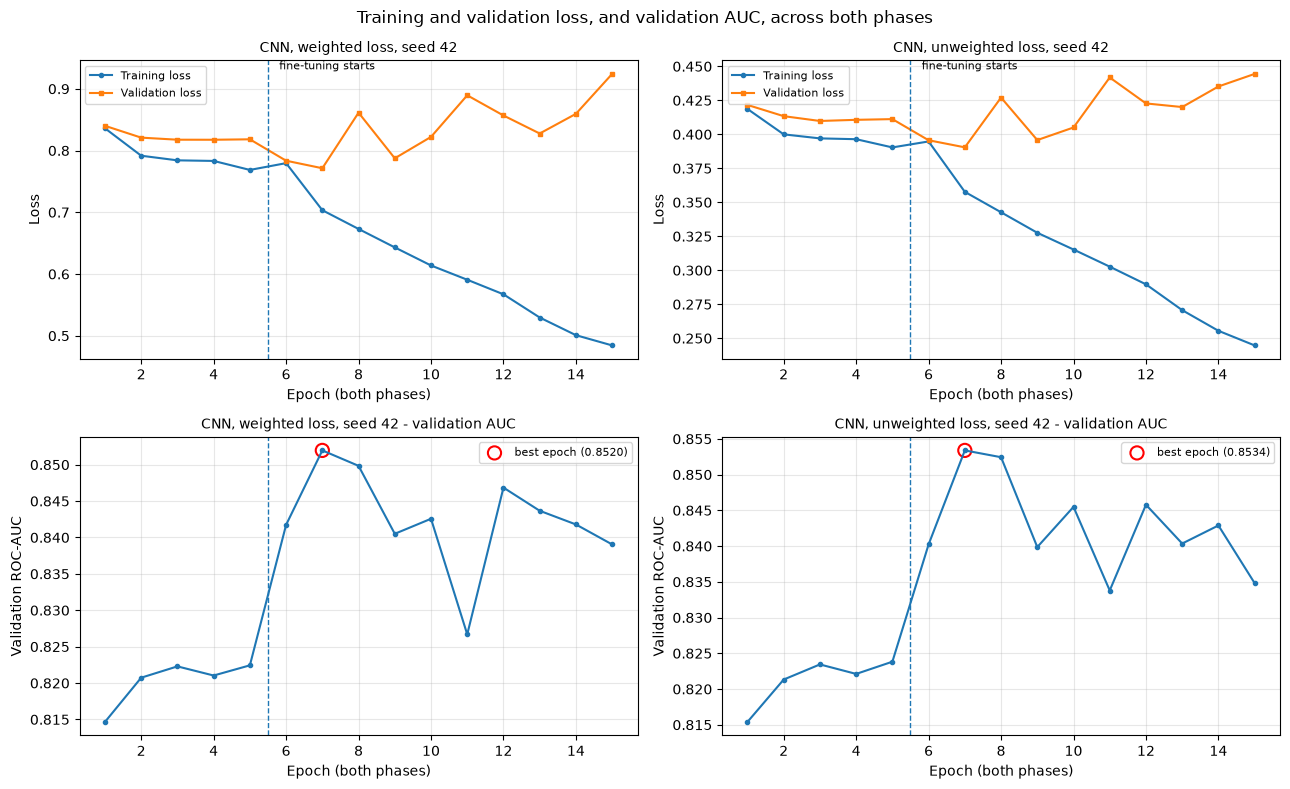


CNN, weighted loss, seed 42
  final epoch:  train_loss 0.4844  val_loss 0.9241  gap +0.4398
  best epoch:   2 of the finetune phase (global epoch 7), val_AUC 0.8520
  val_loss minimum at global epoch 7 of 15

CNN, unweighted loss, seed 42
  final epoch:  train_loss 0.2447  val_loss 0.4444  gap +0.1997
  best epoch:   2 of the finetune phase (global epoch 7), val_AUC 0.8534
  val_loss minimum at global epoch 7 of 15


In [30]:
# Task E - Part 4 (Training and validation loss across epochs)

def plot_history(ax_loss, ax_auc, result):
    """Plot loss curves and validation AUC for one training run."""
    history = result["history"].copy()
    history["global_epoch"] = range(1, len(history) + 1)
    boundary = (history["phase"] == "frozen").sum()

    ax_loss.plot(
        history["global_epoch"],
        history["train_loss"],
        marker="o",
        markersize=3,
        label="Training loss",
    )
    ax_loss.plot(
        history["global_epoch"],
        history["val_loss"],
        marker="s",
        markersize=3,
        label="Validation loss",
    )

    # Mark the transition from frozen-feature training to fine-tuning
    ax_loss.axvline(boundary + 0.5, linestyle="--", linewidth=1)
    ax_loss.text(
        boundary + 0.7,
        ax_loss.get_ylim()[1],
        " fine-tuning starts",
        fontsize=8,
        va="top",
    )

    ax_loss.set_xlabel("Epoch (both phases)")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(result["label"], fontsize=10)
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_auc.plot(
        history["global_epoch"],
        history["val_auc"],
        marker="o",
        markersize=3,
    )

    best = history["val_auc"].idxmax()
    ax_auc.axvline(boundary + 0.5, linestyle="--", linewidth=1)
    ax_auc.scatter(
        history.loc[best, "global_epoch"],
        history.loc[best, "val_auc"],
        s=90,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        label=f"best epoch ({history.loc[best, 'val_auc']:.4f})",
    )

    ax_auc.set_xlabel("Epoch (both phases)")
    ax_auc.set_ylabel("Validation ROC-AUC")
    ax_auc.set_title(f"{result['label']} - validation AUC", fontsize=10)
    ax_auc.legend(fontsize=8)
    ax_auc.grid(alpha=0.3)


runs = [result_weighted, result_unweighted]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for column, result in enumerate(runs):
    plot_history(axes[0, column], axes[1, column], result)

fig.suptitle(
    "Training and validation loss, and validation AUC, across both phases",
    fontsize=12,
)
fig.tight_layout()
plt.show()


# Print values used to support the written discussion
for result in runs:
    history = result["history"]
    final = history.iloc[-1]
    best = history.loc[history["val_auc"].idxmax()]

    print(f"\n{result['label']}")
    print(
        f"  final epoch:  train_loss {final['train_loss']:.4f}  "
        f"val_loss {final['val_loss']:.4f}  "
        f"gap {final['val_loss'] - final['train_loss']:+.4f}"
    )

    best_global = int(np.argmax(history["val_auc"].to_numpy())) + 1
    print(
        f"  best epoch:   {int(best['epoch'])} of the {best['phase']} phase "
        f"(global epoch {best_global}), val_AUC {best['val_auc']:.4f}"
    )

    val_min_position = int(np.argmin(history["val_loss"].to_numpy())) + 1
    print(
        f"  val_loss minimum at global epoch "
        f"{val_min_position} of {len(history)}"
    )

### Underfitting or overfitting?

**Fine-tuning helped:** the weighted model improved from a best validation ROC-AUC of 0.8224 during fixed-feature training to **0.8520 at global epoch 7**, the second fine-tuning epoch.

**Evidence of overfitting appeared after epoch 7:** from that point onward:
- training loss continued to decrease;
- validation loss generally increased from its minimum;
- validation ROC-AUC fluctuated but never exceeded 0.8520.

This means the model continued fitting the training data without improving validation performance. This indicates **overfitting during the later fine-tuning epochs rather than underfitting**.

Therefore, I retained the checkpoint with the highest validation ROC-AUC instead of using the model from the final epoch. The unweighted model showed the same pattern, with its best validation ROC-AUC of **0.8534 also occurring at global epoch 7**.

In [31]:
# Task E - Part 4b (Effect of the class-imbalance strategy on the CNN)

cnn_imbalance_rows = []

for result in [result_unweighted, result_weighted]:
    val_probabilities = result[
        "validation_probabilities"
    ]
    val_labels = result[
        "validation_labels"
    ]

    predictions = (
        val_probabilities >= 0.5
    ).astype(int)

    row = evaluate_predictions(
        val_labels,
        predictions,
        result["label"],
    )

    row["ROC-AUC"] = roc_auc_score(
        val_labels,
        val_probabilities,
    )

    cnn_imbalance_rows.append(row)


cnn_imbalance_comparison = pd.DataFrame(
    cnn_imbalance_rows
).set_index("Model")


print(
    "Effect of positive-class weighting on the CNN "
    "(validation set):"
)

print(
    cnn_imbalance_comparison
    .round(4)
    .to_string()
)

Effect of positive-class weighting on the CNN (validation set):
                                 TN   FP   FN   TP  Accuracy  Sensitivity  Specificity  Precision      F1  ROC-AUC
Model                                                                                                             
CNN, unweighted loss, seed 42  2791  332  387  535    0.8222       0.5803       0.8937     0.6171  0.5981   0.8534
CNN, weighted loss, seed 42    2166  957  144  778    0.7278       0.8438       0.6936     0.4484  0.5856   0.8520


### Headline configuration

The **weighted, fine-tuned CNN** is used as the headline configuration, based only on validation results.

Weighting had little effect on validation ROC-AUC (0.8520 weighted vs 0.8534 unweighted), but it substantially changed the predictions when using the default classification threshold of 0.5, where probabilities ≥ 0.5 are classified as positive and probabilities < 0.5 as negative. At this threshold, sensitivity increased from 0.5803 to 0.8438, while specificity decreased from 0.8937 to 0.6936. Therefore, weighting mainly shifts the model toward detecting more positive cases.

I retained the weighted model to address the class imbalance and reduce the tendency toward predicting the majority negative class. The unweighted model remains the controlled comparison. The three-seed evaluation below therefore uses the weighted, fine-tuned configuration. No test results were used to make this choice.

In [32]:
# Task E - Part 5a (Seed control: retrain the headline configuration with three seeds)

SEEDS = [42, 7, 1234]

# Reuse the existing seed 42 run and train the two additional seeds independently
seed_results = {42: result_weighted}

for seed in SEEDS[1:]:
    seed_results[seed] = train_cnn(
        weighted=True,
        seed=seed,
        label=f"CNN, weighted loss, seed {seed}",
    )


CNN, weighted loss, seed 7  (weighted=True, seed=7)

  frozen: 1,025 trainable parameters, lr=0.001, 5 epochs
    epoch  1  train_loss 0.8408  val_loss 0.8281  val_AUC 0.8146  (22s)  <- best
    epoch  2  train_loss 0.8032  val_loss 0.8261  val_AUC 0.8184  (22s)  <- best
    epoch  3  train_loss 0.7855  val_loss 0.8147  val_AUC 0.8211  (22s)  <- best
    epoch  4  train_loss 0.7770  val_loss 0.8499  val_AUC 0.8238  (22s)  <- best
    epoch  5  train_loss 0.7749  val_loss 0.8734  val_AUC 0.8245  (22s)  <- best

  finetune: 2,161,153 trainable parameters, lr=0.0001, 10 epochs
    epoch  1  train_loss 0.7835  val_loss 0.7809  val_AUC 0.8442  (22s)  <- best
    epoch  2  train_loss 0.7129  val_loss 0.7891  val_AUC 0.8401  (22s)
    epoch  3  train_loss 0.6725  val_loss 0.7631  val_AUC 0.8557  (22s)  <- best
    epoch  4  train_loss 0.6478  val_loss 0.7860  val_AUC 0.8534  (22s)
    epoch  5  train_loss 0.6093  val_loss 0.7876  val_AUC 0.8383  (22s)
    epoch  6  train_loss 0.5995  val_los

In [33]:
# Task E - Part 5b (Evaluate the three CNN seed runs on the test set, report mean and standard deviation, 
# and compare the CNN improvement with the simple baseline)

print("Random seeds used")
print(
    f"  SPLIT_SEED    = {SPLIT_SEED}   "
    "(patient split)"
)
print(
    f"  SIMPLE_BASELINE_SEED = {SIMPLE_BASELINE_SEED}   "
    "(8-feature simple baseline)"
)
print(
    f"  AUGMENT_SEED  = {AUGMENT_SEED}   "
    "(augmentation display)"
)
print(f"  CNN seeds     = {SEEDS}")


# ------------------------------------------------------------
# Final test evaluation
# All model-development decisions are already fixed at this point.
# ------------------------------------------------------------

test_loader = make_loader(
    test_frame,
    evaluation_transform,
    shuffle=False,
)

rows = []

for seed in SEEDS:
    result = seed_results[seed]

    test_probs, test_labels = predict(
        result["model"],
        test_loader,
    )

    result["test_probabilities"] = test_probs
    result["test_labels"] = test_labels

    test_auc = roc_auc_score(
        test_labels,
        test_probs,
    )

    rows.append({
        "Seed": seed,
        "Best validation AUC": result[
            "finetune_val_auc"
        ],
        "Test ROC-AUC": test_auc,
    })


seed_table = pd.DataFrame(
    rows
).set_index("Seed")

print("\nCNN results by seed:")
print(
    seed_table
    .round(4)
    .to_string()
)


cnn_aucs = seed_table[
    "Test ROC-AUC"
].to_numpy()

cnn_mean = cnn_aucs.mean()
cnn_std = cnn_aucs.std(ddof=1)
cnn_range = (
    cnn_aucs.max()
    - cnn_aucs.min()
)


print(
    f"\nCNN test ROC-AUC over "
    f"{len(SEEDS)} seeds:"
)
print(f"  mean  = {cnn_mean:.4f}")
print(f"  std   = {cnn_std:.4f}")
print(
    f"  range = {cnn_range:.4f} "
    f"({cnn_aucs.min():.4f} to "
    f"{cnn_aucs.max():.4f})"
)


# ------------------------------------------------------------
# Final simple-baseline test evaluation
# ------------------------------------------------------------

probs_weighted = probabilities(
    baseline_model,
    Xte,
)

test_probabilities = probs_weighted

baseline_predictions = (
    probs_weighted >= 0.5
).astype(int)

baseline_test_metrics = evaluate_predictions(
    y_test,
    baseline_predictions,
    "Simple baseline, weighted loss",
)

baseline_auc = roc_auc_score(
    y_test,
    probs_weighted,
)

baseline_test_metrics[
    "ROC-AUC"
] = baseline_auc


print(
    "\nFinal simple-baseline test performance "
    "(weighted configuration):"
)

print(
    pd.DataFrame(
        [baseline_test_metrics]
    )
    .set_index("Model")
    .round(4)
    .to_string()
)


improvement = (
    cnn_mean
    - baseline_auc
)


print(
    "\nComparison with the simple baseline:"
)
print(
    f"  simple baseline test ROC-AUC = "
    f"{baseline_auc:.4f}"
)
print(
    f"  CNN mean test ROC-AUC        = "
    f"{cnn_mean:.4f}"
)
print(
    f"  improvement                  = "
    f"{improvement:+.4f}"
)
print(
    f"  CNN run-to-run std           = "
    f"{cnn_std:.4f}"
)

Random seeds used
  SPLIT_SEED    = 42   (patient split)
  SIMPLE_BASELINE_SEED = 42   (8-feature simple baseline)
  AUGMENT_SEED  = 42   (augmentation display)
  CNN seeds     = [42, 7, 1234]

CNN results by seed:
      Best validation AUC  Test ROC-AUC
Seed                                   
42                 0.8520        0.8391
7                  0.8557        0.8457
1234               0.8487        0.8435

CNN test ROC-AUC over 3 seeds:
  mean  = 0.8428
  std   = 0.0034
  range = 0.0066 (0.8391 to 0.8457)

Final simple-baseline test performance (weighted configuration):
                                  TN    FP   FN   TP  Accuracy  Sensitivity  Specificity  Precision      F1  ROC-AUC
Model                                                                                                               
Simple baseline, weighted loss  1991  1001  199  563    0.6803       0.7388       0.6654       0.36  0.4841   0.7715

Comparison with the simple baseline:
  simple baseline test ROC-A

### Explanation

The weighted, fine-tuned CNN was retrained independently using seeds **42, 7, and 1234**. Its test ROC-AUC values were 0.8391, 0.8457, and 0.8435, giving a mean of **0.8428 ± 0.0034 (SD)**.

The weighted simple baseline achieved a test ROC-AUC of **0.7715**, so the CNN improved the mean test ROC-AUC by **0.0712**. This improvement is much larger than the observed CNN run-to-run standard deviation of **0.0034**.

Therefore, the CNN's improvement over the simple baseline is larger than the variation observed across the three CNN training seeds.

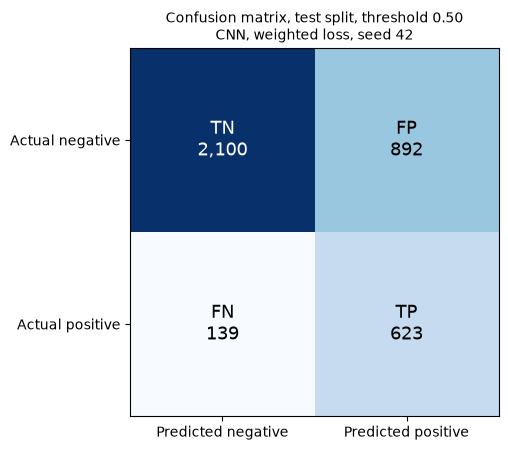

CNN, weighted loss, seed 42, test split, threshold 0.50

  True negatives  2,100      False positives   892
  False negatives   139      True positives    623

  Accuracy     0.7254   (2,723 of 3,754 correct)
  Sensitivity  0.8176   (623 of 762 positives detected)
  Specificity  0.7019   (2,100 of 2,992 negatives cleared)
  Precision    0.4112   (623 of 1,515 flagged are correct)
  F1-score     0.5472   (harmonic mean of precision and sensitivity)


In [34]:
# Task F - Part 1 (From the predicted probabilities, report a confusion matrix, accuracy, sensitivity, specificity, precision and
# F1-score.)

# Use the headline weighted CNN with the default 0.50 threshold
headline = result_weighted
headline_probs = headline["test_probabilities"]
headline_labels = headline["test_labels"]
headline_preds = (headline_probs >= 0.5).astype(int)

matrix = confusion_matrix(headline_labels, headline_preds, labels=[0, 1])
tn, fp, fn, tp = matrix.ravel()

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.imshow(matrix, cmap="Blues")

for i in range(2):
    for j in range(2):
        name = [["TN", "FP"], ["FN", "TP"]][i][j]
        ax.text(
            j,
            i,
            f"{name}\n{matrix[i, j]:,}",
            ha="center",
            va="center",
            fontsize=13,
            color="white" if matrix[i, j] > matrix.max() / 2 else "black",
        )

ax.set_xticks([0, 1], ["Predicted negative", "Predicted positive"])
ax.set_yticks([0, 1], ["Actual negative", "Actual positive"])
ax.set_title(
    f"Confusion matrix, test split, threshold 0.50\n{headline['label']}",
    fontsize=10,
)
fig.tight_layout()
plt.show()

accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1 = 2 * precision * sensitivity / (precision + sensitivity)

print(f"{headline['label']}, test split, threshold 0.50\n")
print(f"  True negatives  {tn:>5,}      False positives {fp:>5,}")
print(f"  False negatives {fn:>5,}      True positives  {tp:>5,}\n")
print(f"  Accuracy     {accuracy:.4f}   ({tp + tn:,} of {len(headline_labels):,} correct)")
print(f"  Sensitivity  {sensitivity:.4f}   ({tp:,} of {tp + fn:,} positives detected)")
print(f"  Specificity  {specificity:.4f}   ({tn:,} of {tn + fp:,} negatives cleared)")
print(f"  Precision    {precision:.4f}   ({tp:,} of {tp + fp:,} flagged are correct)")
print(f"  F1-score     {f1:.4f}   (harmonic mean of precision and sensitivity)")

In [35]:
# Task F - Part 2 (Comparison table: trivial baseline, simple baseline and CNN)

comparison_rows = []

# Trivial baseline: predicts the training majority class for every test image
trivial_preds = np.full_like(
    y_test.astype(int),
    MAJORITY_CLASS,
)

trivial_probs = np.full(
    len(y_test),
    float(MAJORITY_CLASS),
)

trivial_row = evaluate_predictions(
    y_test,
    trivial_preds,
    "Trivial baseline (majority class)",
)

trivial_row["ROC-AUC"] = roc_auc_score(
    y_test,
    trivial_probs,
)

comparison_rows.append(trivial_row)


# Simple baseline: logistic classifier on eight image-summary features
simple_row = evaluate_predictions(
    y_test,
    (probs_weighted >= 0.5).astype(int),
    "Simple baseline (8 features)",
)

simple_row["ROC-AUC"] = roc_auc_score(
    y_test,
    probs_weighted,
)

comparison_rows.append(simple_row)


# CNN: headline configuration, seed 42
cnn_row = evaluate_predictions(
    headline_labels,
    headline_preds,
    "CNN (DenseNet121, fine-tuned)",
)

cnn_row["ROC-AUC"] = roc_auc_score(
    headline_labels,
    headline_probs,
)

comparison_rows.append(cnn_row)


model_comparison = pd.DataFrame(
    comparison_rows
).set_index("Model")

print(
    "All models: test split, threshold 0.50, "
    "identical examinations and metrics\n"
)

print(
    model_comparison
    .round(4)
    .to_string()
)

print("\nCNN row shown above uses seed 42.")

print(
    f"Across three seeds, CNN test ROC-AUC was "
    f"{cnn_mean:.4f} +/- {cnn_std:.4f}."
)

All models: test split, threshold 0.50, identical examinations and metrics

                                     TN    FP   FN   TP  Accuracy  Sensitivity  Specificity  Precision      F1  ROC-AUC
Model                                                                                                                  
Trivial baseline (majority class)  2992     0  762    0    0.7970       0.0000       1.0000     0.0000  0.0000   0.5000
Simple baseline (8 features)       1991  1001  199  563    0.6803       0.7388       0.6654     0.3600  0.4841   0.7715
CNN (DenseNet121, fine-tuned)      2100   892  139  623    0.7254       0.8176       0.7019     0.4112  0.5472   0.8391

CNN row shown above uses seed 42.
Across three seeds, CNN test ROC-AUC was 0.8428 +/- 0.0034.


### No-skill reference

A model with no ability to distinguish positive from negative cases has a ROC-AUC of **0.5**.

For the precision–recall curve, a model with no ability to distinguish the classes would have an average precision equal to the proportion of positive cases in the test set: **0.2030 (20.30%)**.

I will refer to these values as the **no-skill references**.

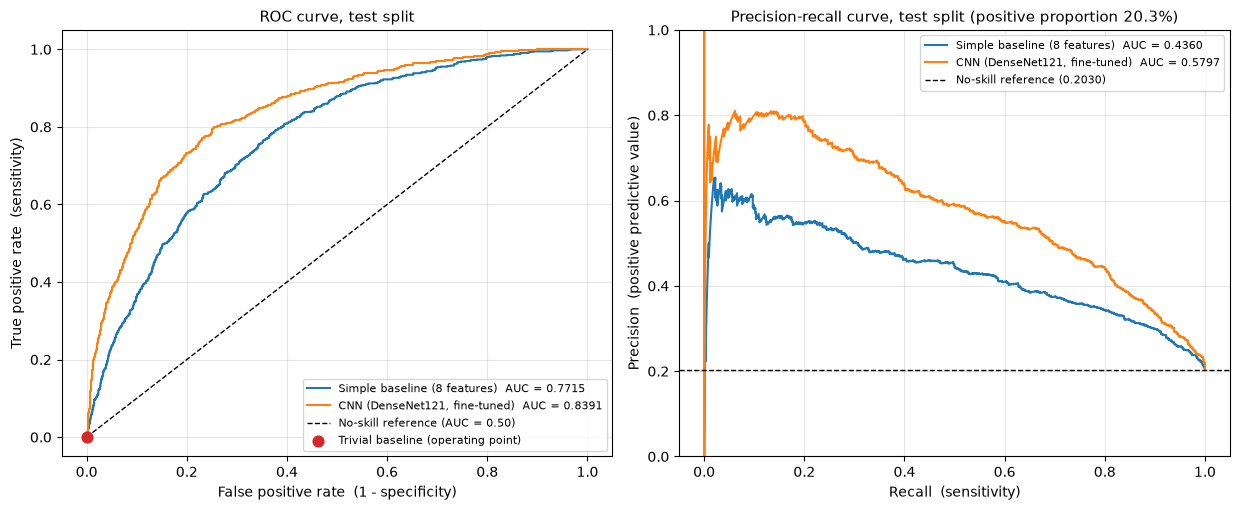

Areas under each curve, test split

  Simple baseline (8 features)
    ROC-AUC = 0.7715
    PR-AUC  = 0.4360   (no-skill reference: 0.2030)
  CNN (DenseNet121, fine-tuned)
    ROC-AUC = 0.8391
    PR-AUC  = 0.5797   (no-skill reference: 0.2030)

Test positives: 762 of 3,754 (20.30%)
Trivial majority-class baseline: ROC-AUC = 0.5000; PR no-skill reference = 0.2030.
Its constant-score curves are represented by the no-skill reference lines rather than plotted separately.


In [36]:
# Task F - Part 3 (ROC and precision-recall curves)

prevalence = headline_labels.mean()

# The trivial baseline has a constant score for every examination.
# Its ROC-AUC is 0.5, while the precision-recall no-skill reference
# equals the positive proportion in the test set.
curves = [
    ("Simple baseline (8 features)", probs_weighted, y_test),
    ("CNN (DenseNet121, fine-tuned)", headline_probs, headline_labels),
]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12.5, 5.2))

for name, probs, labels in curves:
    # ROC curve and area
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    ax_roc.plot(
        fpr,
        tpr,
        label=f"{name}  AUC = {roc_auc:.4f}",
    )

    # Precision-recall curve and area
    precision_curve, recall_curve, _ = precision_recall_curve(
        labels,
        probs,
    )
    pr_auc = auc(recall_curve, precision_curve)

    ax_pr.plot(
        recall_curve,
        precision_curve,
        label=f"{name}  AUC = {pr_auc:.4f}",
    )

# No-skill reference lines
ax_roc.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1,
    label="No-skill reference (AUC = 0.50)",
)

ax_pr.axhline(
    prevalence,
    color="k",
    linestyle="--",
    linewidth=1,
    label=f"No-skill reference ({prevalence:.4f})",
)

# The trivial baseline always predicts negative
ax_roc.scatter(
    [0],
    [0],
    color="tab:red",
    s=60,
    zorder=5,
    label="Trivial baseline (operating point)",
)

ax_roc.set_xlabel("False positive rate  (1 - specificity)")
ax_roc.set_ylabel("True positive rate  (sensitivity)")
ax_roc.set_title("ROC curve, test split", fontsize=11)
ax_roc.legend(fontsize=8, loc="lower right")
ax_roc.grid(alpha=0.3)

ax_pr.set_xlabel("Recall  (sensitivity)")
ax_pr.set_ylabel("Precision  (positive predictive value)")
ax_pr.set_title(
    f"Precision-recall curve, test split "
    f"(positive proportion {prevalence:.1%})",
    fontsize=11,
)
ax_pr.legend(fontsize=8, loc="upper right")
ax_pr.grid(alpha=0.3)
ax_pr.set_ylim(0, 1)

fig.tight_layout()
plt.show()

print("Areas under each curve, test split\n")

for name, probs, labels in curves:
    fpr, tpr, _ = roc_curve(labels, probs)
    precision_curve, recall_curve, _ = precision_recall_curve(
        labels,
        probs,
    )

    roc_auc = auc(fpr, tpr)
    pr_auc = auc(recall_curve, precision_curve)

    print(f"  {name}")
    print(f"    ROC-AUC = {roc_auc:.4f}")
    print(
        f"    PR-AUC  = {pr_auc:.4f}"
        f"   (no-skill reference: {prevalence:.4f})"
    )

print(
    f"\nTest positives: {int(headline_labels.sum()):,} of "
    f"{len(headline_labels):,} ({prevalence:.2%})"
)

print(
    "Trivial majority-class baseline: "
    f"ROC-AUC = 0.5000; "
    f"PR no-skill reference = {prevalence:.4f}."
)

print(
    "Its constant-score curves are represented by the "
    "no-skill reference lines rather than plotted separately."
)

### Which curve is more informative here?

The **precision–recall curve is more informative for the observed class balance** because only 20.30% of the test examinations are positive. It focuses on the positive class by showing the trade-off between sensitivity (how many positives are detected) and precision (how many predicted positives are actually positive).

This is important here because false positives are substantial. Of the 762 examinations that were actually positive, the CNN correctly detected 623, giving a sensitivity of 0.8176. However, the CNN predicted 1,515 examinations as positive in total: 623 were actually positive and 892 were actually negative. Therefore, only 41.12% of the model's positive predictions were correct, giving a precision of 0.4112.

The ROC curve remains useful for measuring how well the model separates positive from negative examinations across thresholds, but it does not directly show how many of the model's positive predictions are actually correct. Therefore, for this imbalanced test set, the precision–recall curve gives a clearer view of positive-class performance.

In [37]:
# Task F - Part 4 (Two operating thresholds, selected on validation and frozen)

# Select both thresholds using validation predictions only
val_loader = make_loader(val_frame, evaluation_transform, shuffle=False)
val_probs, val_labels = predict(headline["model"], val_loader)

print(
    f"Validation: {len(val_labels):,} examinations, "
    f"{int(val_labels.sum()):,} positive ({val_labels.mean():.2%})\n"
)


def sensitivity_specificity(labels, probs, threshold):
    predictions = (probs >= threshold).astype(int)
    tp = int(((predictions == 1) & (labels == 1)).sum())
    fn = int(((predictions == 0) & (labels == 1)).sum())
    tn = int(((predictions == 0) & (labels == 0)).sum())
    fp = int(((predictions == 1) & (labels == 0)).sum())
    return tp / (tp + fn), tn / (tn + fp)


# Evaluate every distinct validation probability as a candidate threshold
candidates = np.unique(val_probs)
measured = np.array([
    sensitivity_specificity(val_labels, val_probs, threshold)
    for threshold in candidates
])
val_sensitivity, val_specificity = measured[:, 0], measured[:, 1]

# Screening: choose the highest threshold that still achieves the sensitivity target
SENSITIVITY_TARGET = 0.90
eligible = candidates[val_sensitivity >= SENSITIVITY_TARGET]
SCREENING_THRESHOLD = float(eligible.max())

# Specificity: choose the lowest threshold that achieves the specificity target
SPECIFICITY_TARGET = 0.95
eligible = candidates[val_specificity >= SPECIFICITY_TARGET]
SPECIFICITY_THRESHOLD = float(eligible.min())

for name, threshold, rule in [
    (
        "Screening",
        SCREENING_THRESHOLD,
        f"highest threshold with validation sensitivity >= {SENSITIVITY_TARGET:.2f}",
    ),
    (
        "Specificity",
        SPECIFICITY_THRESHOLD,
        f"lowest threshold with validation specificity >= {SPECIFICITY_TARGET:.2f}",
    ),
]:
    sens, spec = sensitivity_specificity(val_labels, val_probs, threshold)
    print(f"{name} threshold = {threshold:.4f}")
    print(f"  rule: {rule}")
    print(
        f"  validation sensitivity {sens:.4f}, "
        f"specificity {spec:.4f}\n"
    )

print(
    "Both thresholds are now frozen and applied to the "
    "test split unchanged.\n"
)


# Apply the frozen thresholds to the test split
threshold_rows = []

for name, threshold in [
    ("Default (0.50)", 0.50),
    (
        f"Screening ({SCREENING_THRESHOLD:.4f})",
        SCREENING_THRESHOLD,
    ),
    (
        f"Specificity ({SPECIFICITY_THRESHOLD:.4f})",
        SPECIFICITY_THRESHOLD,
    ),
]:
    predictions = (headline_probs >= threshold).astype(int)
    threshold_rows.append(
        evaluate_predictions(headline_labels, predictions, name)
    )

threshold_comparison = pd.DataFrame(
    threshold_rows
).set_index("Model")
threshold_comparison.index.name = "Operating point"

print(
    "Test split at each operating point "
    "(same model, same predictions, different threshold):"
)
print(threshold_comparison.round(4).to_string())

print(
    f"\nMissed positives: "
    f"{threshold_comparison['FN'].iloc[1]} at the screening threshold, "
    f"{threshold_comparison['FN'].iloc[2]} at the specificity threshold, "
    f"out of {int(headline_labels.sum()):,} test positives."
)

Validation: 4,045 examinations, 922 positive (22.79%)

Screening threshold = 0.3890
  rule: highest threshold with validation sensitivity >= 0.90
  validation sensitivity 0.9002, specificity 0.6135

Specificity threshold = 0.8896
  rule: lowest threshold with validation specificity >= 0.95
  validation sensitivity 0.4111, specificity 0.9500

Both thresholds are now frozen and applied to the test split unchanged.

Test split at each operating point (same model, same predictions, different threshold):
                        TN    FP   FN   TP  Accuracy  Sensitivity  Specificity  Precision      F1
Operating point                                                                                  
Default (0.50)        2100   892  139  623    0.7254       0.8176       0.7019     0.4112  0.5472
Screening (0.3890)    1872  1120  105  657    0.6737       0.8622       0.6257     0.3697  0.5175
Specificity (0.8896)  2832   160  466  296    0.8332       0.3885       0.9465     0.6491  0.4860

Miss

### Operating thresholds

Both thresholds were selected using validation predictions only, then frozen and applied unchanged to the test set.

**Screening threshold = 0.3890:** the highest threshold that achieved at least 0.90 validation sensitivity. On the test set, sensitivity was 0.8622 and specificity was 0.6257, with 105 of 762 positives missed. This shows that the 0.90 sensitivity achieved on validation did not transfer exactly to unseen data.

**Specificity threshold = 0.8896:** the lowest threshold that achieved at least 0.95 validation specificity. On the test set, specificity was 0.9465 and sensitivity was 0.3885. False positives decreased from 892 at the default 0.50 threshold to 160, but 466 of 762 positives were missed.

The screening threshold detects more positives at the cost of more false positives, while the specificity threshold reduces false positives at the cost of missing more positives.

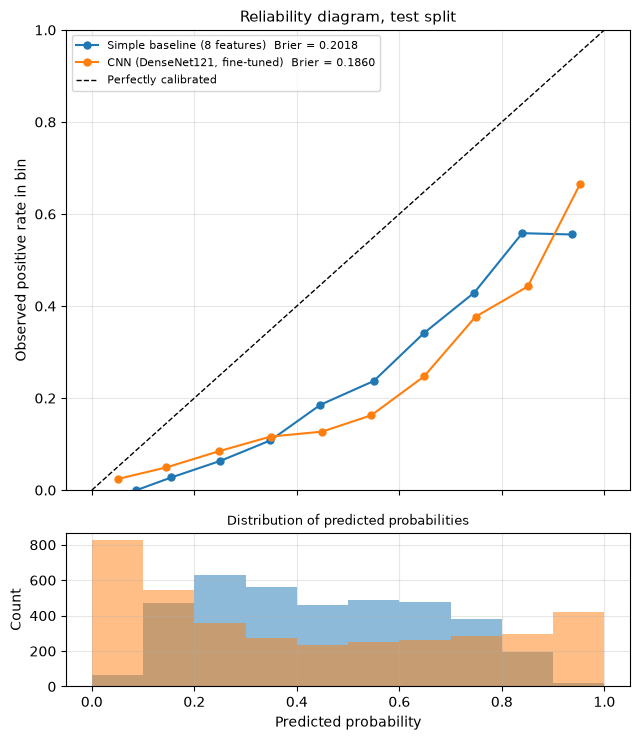

Discrimination and calibration are different properties:

  Simple baseline (8 features)
    ROC-AUC (discrimination) = 0.7715
    Brier score (probability accuracy) = 0.2018 (lower is better)
    mean predicted probability = 0.4485   against actual positive proportion = 0.2030
  CNN (DenseNet121, fine-tuned)
    ROC-AUC (discrimination) = 0.8391
    Brier score (probability accuracy) = 0.1860 (lower is better)
    mean predicted probability = 0.4218   against actual positive proportion = 0.2030


In [38]:
# Task F - Part 5 (Reliability diagram)

N_BINS = 10
curve_colours = ["C0", "C1"]

fig, (ax_rel, ax_hist) = plt.subplots(
    2,
    1,
    figsize=(6.5, 7.5),
    height_ratios=[3, 1],
    sharex=True,
)

for (name, probs, labels), colour in zip(curves, curve_colours):
    # Compare mean predicted probability with observed positive rate in each bin
    observed, predicted = calibration_curve(
        labels,
        probs,
        n_bins=N_BINS,
        strategy="uniform",
    )
    brier = brier_score_loss(labels, probs)

    ax_rel.plot(
        predicted,
        observed,
        marker="o",
        markersize=5,
        color=colour,
        label=f"{name}  Brier = {brier:.4f}",
    )
    ax_hist.hist(
        probs,
        bins=N_BINS,
        range=(0, 1),
        alpha=0.5,
        color=colour,
        label=name,
    )

# Perfect calibration
ax_rel.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1,
    label="Perfectly calibrated",
)

ax_rel.set_ylabel("Observed positive rate in bin")
ax_rel.set_title("Reliability diagram, test split", fontsize=11)
ax_rel.legend(fontsize=8, loc="upper left")
ax_rel.grid(alpha=0.3)
ax_rel.set_ylim(0, 1)

ax_hist.set_xlabel("Predicted probability")
ax_hist.set_ylabel("Count")
ax_hist.set_title("Distribution of predicted probabilities", fontsize=9)
ax_hist.grid(alpha=0.3)

fig.tight_layout()
plt.show()


print("Discrimination and calibration are different properties:\n")

for name, probs, labels in curves:
    print(f"  {name}")
    print(f"    ROC-AUC (discrimination) = {roc_auc_score(labels, probs):.4f}")
    print(
        f"    Brier score (probability accuracy) = "
        f"{brier_score_loss(labels, probs):.4f} (lower is better)"
    )
    print(
        f"    mean predicted probability = {probs.mean():.4f}"
        f"   against actual positive proportion = {labels.mean():.4f}"
    )

### Discrimination and calibration

**Discrimination** measures how well the model separates positive from negative examinations. The CNN achieved a ROC-AUC of **0.8391**, compared with **0.7715** for the simple baseline.

**Calibration** measures whether predicted probabilities match what actually happens. For example, among examinations given a predicted probability of 0.70, a well-calibrated model should have about 70% positives. In the reliability diagram, a perfectly calibrated model would follow the diagonal line.

The CNN is not well calibrated: its mean predicted probability was **0.4218**, while only **0.2030 (20.30%)** of the test examinations were actually positive, and its reliability curve deviates from the diagonal. Therefore, its predicted probabilities should not be interpreted directly as actual clinical probabilities.

The CNN's Brier score was **0.1860**, compared with **0.2018** for the simple baseline. However, Brier score reflects both discrimination and calibration, so the lower score alone does not prove better calibration.

Panel selection seed: 42


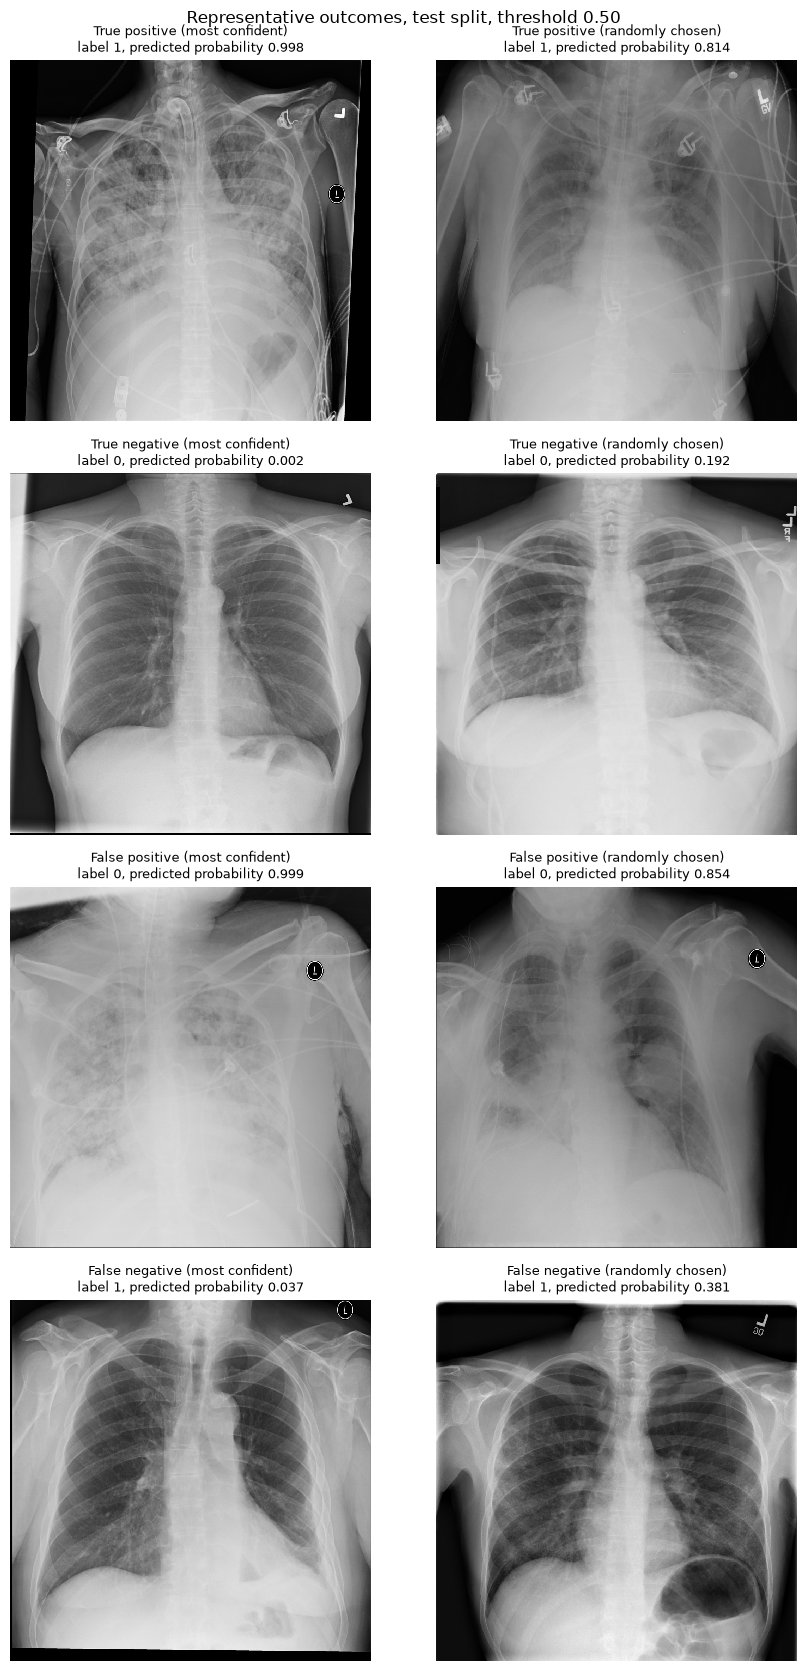

Counts at threshold 0.50:
  True positive     623   mean predicted probability 0.841
  True negative   2,100   mean predicted probability 0.178
  False positive    892   mean predicted probability 0.727
  False negative    139   mean predicted probability 0.270


In [39]:
# Task G - Part 1 (Representative TP, TN, FP and FN examples)

# Use the fixed headline CNN (weighted, fine-tuned, seed 42)
# on the test set at the default 0.50 threshold
test_uids = test_frame["SOPInstanceUID"].to_numpy()

assert len(test_uids) == len(headline_probs), "Test UIDs and predictions are misaligned."

outcomes = pd.DataFrame({
    "SOPInstanceUID": test_uids,
    "label": headline_labels.astype(int),
    "probability": headline_probs,
})

outcomes["prediction"] = (outcomes["probability"] >= 0.5).astype(int)

categories = {
    "True positive": (outcomes["label"] == 1) & (outcomes["prediction"] == 1),
    "True negative": (outcomes["label"] == 0) & (outcomes["prediction"] == 0),
    "False positive": (outcomes["label"] == 0) & (outcomes["prediction"] == 1),
    "False negative": (outcomes["label"] == 1) & (outcomes["prediction"] == 0),
}

# Select one confident case and one random case from each category
PANEL_SEED = 42
rng = np.random.RandomState(PANEL_SEED)

print(f"Panel selection seed: {PANEL_SEED}")

selected = []

for name, mask in categories.items():
    subset = outcomes[mask].copy()

    if name.endswith("positive"):
        confidence = subset["probability"]
    else:
        confidence = 1 - subset["probability"]

    most_confident = subset.loc[confidence.idxmax()]
    selected.append((name, "most confident", most_confident))

    remaining = subset.drop(index=most_confident.name)
    random_case = remaining.loc[rng.choice(remaining.index)]
    selected.append((name, "randomly chosen", random_case))

fig, axes = plt.subplots(4, 2, figsize=(9, 17))

for ax, (name, how, row) in zip(axes.ravel(), selected):
    dicom = pydicom.dcmread(path_by_uid[row["SOPInstanceUID"]])
    cmap = (
        "gray_r"
        if str(dicom.PhotometricInterpretation) == "MONOCHROME1"
        else "gray"
    )

    ax.imshow(
        dicom.pixel_array,
        cmap=cmap,
        interpolation="nearest",
    )
    ax.set_title(
        f"{name} ({how})\n"
        f"label {int(row['label'])}, "
        f"predicted probability {row['probability']:.3f}",
        fontsize=9,
    )
    ax.axis("off")

fig.suptitle(
    "Representative outcomes, test split, threshold 0.50",
    fontsize=12,
)
fig.tight_layout()
plt.show()


print("Counts at threshold 0.50:")

for name, mask in categories.items():
    subset = outcomes[mask]
    print(
        f"  {name:<15} {len(subset):>5,}   "
        f"mean predicted probability {subset['probability'].mean():.3f}"
    )

In [40]:
# Task G - Part 2 (Subgroup performance)

# ViewPosition and PatientSex are read from the test DICOM headers
subgroup_records = []

for uid in test_uids:
    header = pydicom.dcmread(path_by_uid[uid], stop_before_pixels=True)
    subgroup_records.append({
        "SOPInstanceUID": uid,
        "ViewPosition": str(getattr(header, "ViewPosition", "Missing")),
        "PatientSex": str(getattr(header, "PatientSex", "Missing")),
    })

subgroups = outcomes.merge(
    pd.DataFrame(subgroup_records),
    on="SOPInstanceUID",
    validate="one_to_one",
)


def subgroup_metrics(frame, name):
    """Calculate performance metrics for one subgroup."""
    row = evaluate_predictions(
        frame["label"].to_numpy(),
        frame["prediction"].to_numpy(),
        name,
    )
    row["n"] = len(frame)
    row["Positives"] = int(frame["label"].sum())
    row["Prevalence"] = frame["label"].mean()
    row["ROC-AUC"] = (
        roc_auc_score(frame["label"], frame["probability"])
        if frame["label"].nunique() > 1
        else np.nan
    )
    return row


for field in ["ViewPosition", "PatientSex"]:
    rows = [
        subgroup_metrics(
            subgroups[subgroups[field] == value],
            f"{field} = {value}",
        )
        for value in sorted(subgroups[field].unique())
    ]

    rows.append(subgroup_metrics(subgroups, "All test examinations"))

    table = (
        pd.DataFrame(rows)
        .set_index("Model")
        .rename_axis(None)
    )

    columns = [
        "n",
        "Positives",
        "Prevalence",
        "ROC-AUC",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1",
        "Accuracy",
    ]

    print(f"\n{field}, test split, threshold 0.50")
    print(table[columns].round(4).to_string())


ViewPosition, test split, threshold 0.50
                          n  Positives  Prevalence  ROC-AUC  Sensitivity  Specificity  Precision      F1  Accuracy
ViewPosition = AP      1708        585      0.3425   0.7938       0.9145       0.4212     0.4515  0.6045    0.5902
ViewPosition = PA      2046        177      0.0865   0.7755       0.4972       0.8705     0.2667  0.3471    0.8382
All test examinations  3754        762      0.2030   0.8391       0.8176       0.7019     0.4112  0.5472    0.7254

PatientSex, test split, threshold 0.50
                          n  Positives  Prevalence  ROC-AUC  Sensitivity  Specificity  Precision      F1  Accuracy
PatientSex = F         1620        312      0.1926   0.8449       0.8173       0.7110     0.4028  0.5397    0.7315
PatientSex = M         2134        450      0.2109   0.8346       0.8178       0.6948     0.4172  0.5526    0.7207
All test examinations  3754        762      0.2030   0.8391       0.8176       0.7019     0.4112  0.5472    0.725

### Subgroup performance

Performance was examined by **patient sex** and **projection (AP/PA)** on the test set at threshold 0.50.

**Patient sex:** female examinations (n = 1,620) had ROC-AUC 0.8449, sensitivity 0.8173, and specificity 0.7110. Male examinations (n = 2,134) had ROC-AUC 0.8346, sensitivity 0.8178, and specificity 0.6948. Performance was therefore similar between the two groups.

**Projection:** AP examinations (n = 1,708) had sensitivity 0.9145 and specificity 0.4212, while PA examinations (n = 2,046) had sensitivity 0.4972 and specificity 0.8705. Their ROC-AUC values were more similar (0.7938 AP vs 0.7755 PA), while sensitivity and specificity differed much more at the fixed 0.50 threshold.

The PA group had only 177 positive examinations compared with 585 for AP, so its sensitivity result should be interpreted with more caution. The AP/PA differences show projection-dependent model behaviour but do not prove that projection itself caused the predictions.

In [41]:
# Task G - Part 3a (Grad-CAM: implementation and layer selection)

# The layer used for Grad-CAM. See the markdown below for the justification
GRADCAM_LAYER_NAME = "features.denseblock4"


def grad_cam(model, image_tensor, layer):
    """Return a Grad-CAM heatmap and the model's predicted probability."""
    model.eval()

    captured = {}

    def forward_hook(_module, _input, output):
        # Retain gradients on the activation tensor for Grad-CAM
        output.retain_grad()
        captured["activation"] = output

    handle = layer.register_forward_hook(forward_hook)

    try:
        batch = image_tensor.unsqueeze(0).to(DEVICE)
        logit = model(batch)

        model.zero_grad()

        # Use the positive-class logit as the Grad-CAM target
        logit.backward()

        activation = captured["activation"][0]
        gradient = captured["activation"].grad[0]

        # Grad-CAM channel weights are the spatial mean of the gradients
        weights = gradient.mean(dim=(1, 2), keepdim=True)

        # Keep only positive contributions to the target class
        cam = F.relu((weights * activation).sum(dim=0))

        cam = F.interpolate(
            cam.unsqueeze(0).unsqueeze(0),
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode="bilinear",
            align_corners=False,
        ).squeeze()

        cam = cam - cam.min()

        if cam.max() > 0:
            cam = cam / cam.max()

        return cam.detach().cpu().numpy(), torch.sigmoid(logit).item()

    finally:
        handle.remove()


# Resolve the selected layer by name
gradcam_layer = headline["model"]

for part in GRADCAM_LAYER_NAME.split("."):
    gradcam_layer = getattr(gradcam_layer, part)

print(f"Grad-CAM layer: {GRADCAM_LAYER_NAME}")
print(f"  module type: {type(gradcam_layer).__name__}")

# Confirm that the selected layer retains spatial dimensions
probe_image = ChestXrayDataset(
    test_frame.head(1),
    path_by_uid,
    evaluation_transform,
)[0][0]

probe_capture = {}

handle = gradcam_layer.register_forward_hook(
    lambda _m, _i, output: probe_capture.update(shape=output.shape)
)

with torch.no_grad():
    headline["model"](probe_image.unsqueeze(0).to(DEVICE))

handle.remove()

print(
    f"  output shape: {tuple(probe_capture['shape'])}"
    f"  (spatial resolution "
    f"{probe_capture['shape'][2]} x {probe_capture['shape'][3]})"
)

Grad-CAM layer: features.denseblock4
  module type: _DenseBlock
  output shape: (1, 1024, 7, 7)  (spatial resolution 7 x 7)


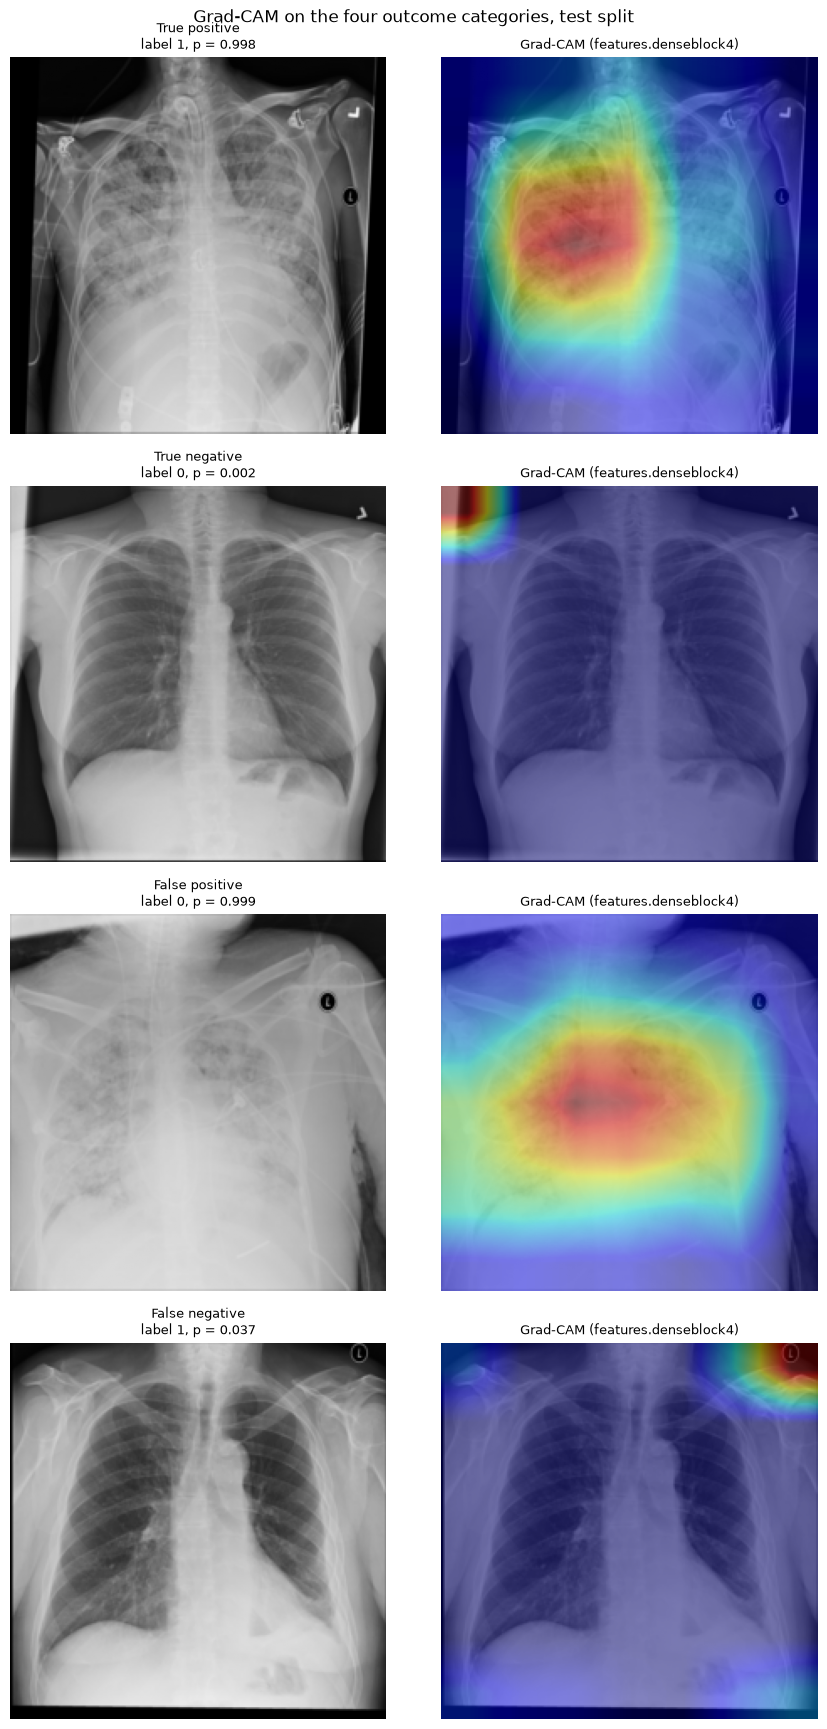

Layer: features.denseblock4
Images: 4 (2 correct, 2 incorrect)


In [42]:
# Task G - Part 3b (Grad-CAM for four test images: two correct, two incorrect)

# Use the same most-confident TP, TN, FP and FN cases selected in Part 1
gradcam_cases = [
    (name, how, row)
    for name, how, row in selected
    if how == "most confident"
]

fig, axes = plt.subplots(
    len(gradcam_cases),
    2,
    figsize=(9, 4.4 * len(gradcam_cases)),
)

for (name, _how, row), (ax_image, ax_cam) in zip(gradcam_cases, axes):
    uid = row["SOPInstanceUID"]

    # Use the same preprocessed tensor that the model receives
    frame_row = test_frame[test_frame["SOPInstanceUID"] == uid]
    image_tensor = ChestXrayDataset(
        frame_row,
        path_by_uid,
        evaluation_transform,
    )[0][0]

    heatmap, probability = grad_cam(
        headline["model"],
        image_tensor,
        gradcam_layer,
    )
    display_image = denormalize(image_tensor)

    ax_image.imshow(
        display_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax_image.set_title(
        f"{name}\n"
        f"label {int(row['label'])}, p = {probability:.3f}",
        fontsize=9,
    )
    ax_image.axis("off")

    ax_cam.imshow(
        display_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax_cam.imshow(
        heatmap,
        cmap="jet",
        alpha=0.45,
    )
    ax_cam.set_title(
        f"Grad-CAM ({GRADCAM_LAYER_NAME})",
        fontsize=9,
    )
    ax_cam.axis("off")

fig.suptitle(
    "Grad-CAM on the four outcome categories, test split",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print(f"Layer: {GRADCAM_LAYER_NAME}")
print(
    f"Images: {len(gradcam_cases)} "
    f"({sum(1 for n, _, _ in gradcam_cases if n.startswith('True'))} correct, "
    f"{sum(1 for n, _, _ in gradcam_cases if n.startswith('False'))} incorrect)"
)

### Grad-CAM: layer selection

**Layer used: `features.denseblock4`.** This is DenseNet121's final dense convolutional block. For one image, it produces 1,024 feature maps with a spatial resolution of 7 × 7.

I selected this layer because it is deep enough to contain high-level features related to the prediction while still retaining spatial information needed for Grad-CAM. Grad-CAM uses the gradients of the positive-class output to weight and combine these feature maps into a 7 × 7 heatmap, which is then resized to 224 × 224 for visualization.

The Grad-CAM heatmap is originally only 7 × 7 and is enlarged to 224 × 224 for display. It can therefore show the general regions the model responded to, but not precisely locate small anatomical features.

### Lung regions or possible shortcuts?

The **true-positive and false-positive** examples show their strongest Grad-CAM activation mainly within the chest/lung regions. This suggests that lung appearance contributes to positive predictions. However, the false-positive example shows that lung-region activation does not always lead to the correct classification.

The **true-negative and false-negative** examples show their strongest activation near image borders or marker regions, suggesting that the model may also respond to non-lung features. Each Grad-CAM heatmap is normalized separately, so its strongest region is displayed at maximum intensity. Therefore, the bright border regions show where activation was strongest within those images, but their intensity cannot be directly compared with the activation strength in the other examples.

The AP/PA subgroup results also showed different behaviour at the same 0.50 threshold, suggesting that acquisition characteristics may affect model predictions.

Overall, the model appears to use lung-region information, but there are also signs that it may respond to non-lung features. **Grad-CAM shows where the model responds, but it cannot prove that a highlighted region caused the prediction or that the model is using it as a shortcut.**

In [43]:
# Bonus Question 1 - Part 1 (Construct test sets with shifted positive prevalence)

# Keep one class unchanged and subsample only the other class
BONUS_SEED = 42
rng = np.random.RandomState(BONUS_SEED)

print(f"Prevalence-subsampling seed: {BONUS_SEED}")

bonus_frame = pd.DataFrame({
    "label": headline_labels.astype(int),
    "probability": headline_probs,
})

positive_rows = bonus_frame[bonus_frame["label"] == 1]
negative_rows = bonus_frame[bonus_frame["label"] == 0]

# Approximately 10% positive: keep all negatives and subsample positives
n_positive_10 = round(
    0.10 * len(negative_rows) / (1 - 0.10)
)
positive_10 = positive_rows.sample(
    n=n_positive_10,
    random_state=rng,
)

test_shift_10 = pd.concat(
    [negative_rows, positive_10],
    ignore_index=True,
).sample(
    frac=1,
    random_state=rng,
).reset_index(drop=True)

# Approximately 40% positive: keep all positives and subsample negatives
n_negative_40 = round(
    len(positive_rows) * (1 - 0.40) / 0.40
)
negative_40 = negative_rows.sample(
    n=n_negative_40,
    random_state=rng,
)

test_shift_40 = pd.concat(
    [positive_rows, negative_40],
    ignore_index=True,
).sample(
    frac=1,
    random_state=rng,
).reset_index(drop=True)

print("Shifted test sets created from the original test predictions:")
print(
    f"  Original: {len(bonus_frame):,} examinations, "
    f"{bonus_frame['label'].mean():.2%} positive"
)
print(
    f"  ~10% set: {len(test_shift_10):,} examinations, "
    f"{test_shift_10['label'].sum():,} positive "
    f"({test_shift_10['label'].mean():.2%})"
)
print(
    f"  ~40% set: {len(test_shift_40):,} examinations, "
    f"{test_shift_40['label'].sum():,} positive "
    f"({test_shift_40['label'].mean():.2%})"
)

Prevalence-subsampling seed: 42
Shifted test sets created from the original test predictions:
  Original: 3,754 examinations, 20.30% positive
  ~10% set: 3,324 examinations, 332 positive (9.99%)
  ~40% set: 1,905 examinations, 762 positive (40.00%)


In [44]:
# Bonus Question 1 - Part 2 (Evaluate the frozen screening threshold under prevalence shift)

def bonus_metrics(frame, name):
    labels = frame["label"].to_numpy()
    probabilities = frame["probability"].to_numpy()
    predictions = (probabilities >= SCREENING_THRESHOLD).astype(int)

    row = evaluate_predictions(labels, predictions, name)
    row["ROC-AUC"] = roc_auc_score(labels, probabilities)
    row["Prevalence"] = labels.mean()

    return row


bonus_rows = [
    bonus_metrics(test_shift_10, "~10% positive prevalence"),
    bonus_metrics(test_shift_40, "~40% positive prevalence"),
]

bonus_comparison = (
    pd.DataFrame(bonus_rows)
    .set_index("Model")
    .rename_axis(None)
)

columns = [
    "Prevalence",
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1",
    "ROC-AUC",
]

print(f"Frozen screening threshold = {SCREENING_THRESHOLD:.4f}\n")
print("Performance under shifted test-set prevalence:")
print(bonus_comparison[columns].round(4).to_string())

print("\nNo retraining or threshold adjustment was performed.")

Frozen screening threshold = 0.3890

Performance under shifted test-set prevalence:
                          Prevalence  Sensitivity  Specificity  Precision      F1  ROC-AUC
~10% positive prevalence      0.0999       0.8765       0.6257     0.2062  0.3339   0.8494
~40% positive prevalence      0.4000       0.8622       0.6159     0.5995  0.7072   0.8382

No retraining or threshold adjustment was performed.


### Bonus 1: Prevalence shift and threshold transfer

Two additional test sets were created without retraining the model or changing the frozen screening threshold of 0.3890. The first contained approximately 10% positive examinations and the second approximately 40%.

The largest effect of changing prevalence was on **precision and F1**. At 9.99% prevalence, precision was 0.2062 and F1 was 0.3339. At 40.00% prevalence, these increased substantially to 0.5995 and 0.7072. In comparison, sensitivity, specificity, and ROC-AUC changed much less between the two test sets.

This happens because precision depends on how many of the model's positive predictions are actually positive. When positive cases are less common, false positives make up a larger proportion of all positive predictions, so precision falls. F1 also falls because it combines precision and sensitivity. Sensitivity and specificity depend on performance within the positive and negative classes separately, while ROC-AUC measures how well positive examinations are ranked above negative examinations. They therefore depend less directly on class prevalence. The small differences in these metrics occurred because the two test sets contained different subsets of examinations.

The model's ability to distinguish positive from negative examinations changed relatively little between the two prevalence settings. However, the reliability of its positive predictions changed substantially when the proportion of positive cases changed. Performance should therefore be evaluated using a population that reflects the intended deployment setting.

Image size: 224 x 224
Border area masked: 29.56%
Control area masked: 29.57%
Area difference: 0.01%


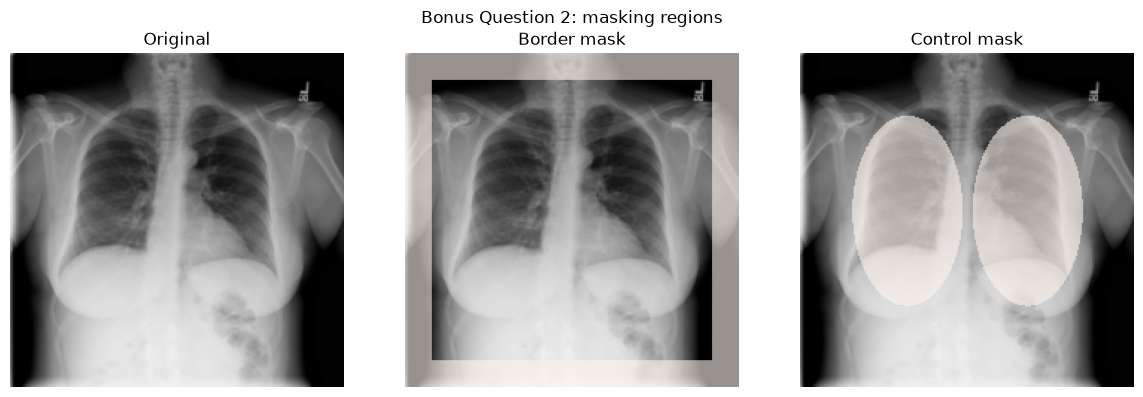

In [45]:
# Bonus Question 2 - Part 1 (Construct deterministic border and control masks)

MASK_FRACTION = 0.08


def make_masks(height, width):
    """
    Construct:
      1. an 8% outer-border mask;
      2. an approximately equal-area control mask positioned
         within the expected lung fields.

    The control mask uses two deterministic elliptical regions.
    This is an approximate anatomical control rather than a segmentation:
    no lung segmentation masks are available in this assignment.
    """

    # ------------------------------------------------------------
    # Border mask
    # ------------------------------------------------------------
    border = np.zeros(
        (height, width),
        dtype=bool,
    )

    border_h = round(
        height * MASK_FRACTION
    )
    border_w = round(
        width * MASK_FRACTION
    )

    border[:border_h, :] = True
    border[-border_h:, :] = True
    border[:, :border_w] = True
    border[:, -border_w:] = True

    # ------------------------------------------------------------
    # Control mask
    # ------------------------------------------------------------
    # Two symmetric ellipses approximate the bilateral lung fields.
    # Their total area is approximately equal to the 8% border area.
    yy, xx = np.ogrid[
        :height,
        :width,
    ]

    centre_y = 0.47 * height

    left_centre_x = 0.32 * width
    right_centre_x = 0.68 * width

    radius_x = 0.165 * width
    radius_y = 0.285 * height

    left_lung = (
        ((xx - left_centre_x) / radius_x) ** 2
        + ((yy - centre_y) / radius_y) ** 2
        <= 1
    )

    right_lung = (
        ((xx - right_centre_x) / radius_x) ** 2
        + ((yy - centre_y) / radius_y) ** 2
        <= 1
    )

    control = left_lung | right_lung

    return border, control


def apply_mask(image_tensor, mask):
    """
    Mask pixels in image space, then restore the model's
    three-channel ImageNet normalisation.
    """

    image = denormalize(
        image_tensor
    ).clone()

    image[mask] = 0.0

    image = (
        image
        .unsqueeze(0)
        .repeat(3, 1, 1)
    )

    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image.dtype,
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        dtype=image.dtype,
    ).view(3, 1, 1)

    return (
        image - mean
    ) / std


sample_image = ChestXrayDataset(
    test_frame.head(1),
    path_by_uid,
    evaluation_transform,
)[0][0]

height, width = sample_image.shape[-2:]

border_mask, control_mask = make_masks(
    height,
    width,
)


print(
    f"Image size: "
    f"{height} x {width}"
)

print(
    f"Border area masked: "
    f"{border_mask.mean():.2%}"
)

print(
    f"Control area masked: "
    f"{control_mask.mean():.2%}"
)

print(
    f"Area difference: "
    f"{abs(border_mask.mean() - control_mask.mean()):.2%}"
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
)

display_image = denormalize(
    sample_image
)


axes[0].imshow(
    display_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)

axes[0].set_title(
    "Original"
)

axes[0].axis(
    "off"
)


axes[1].imshow(
    display_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)

axes[1].imshow(
    np.ma.masked_where(
        ~border_mask,
        border_mask,
    ),
    cmap="Reds",
    alpha=0.6,
)

axes[1].set_title(
    "Border mask"
)

axes[1].axis(
    "off"
)


axes[2].imshow(
    display_image,
    cmap="gray",
    vmin=0,
    vmax=1,
)

axes[2].imshow(
    np.ma.masked_where(
        ~control_mask,
        control_mask,
    ),
    cmap="Reds",
    alpha=0.6,
)

axes[2].set_title(
    "Control mask"
)

axes[2].axis(
    "off"
)


fig.suptitle(
    "Bonus Question 2: masking regions",
    fontsize=12,
)

fig.tight_layout()

plt.show()

In [46]:
# Bonus Question 2 - Part 2 (Compare probability changes after border and control masking)

model = headline["model"]
model.eval()

records = []

for _, row in test_frame.iterrows():
    uid = row["SOPInstanceUID"]

    image_tensor = ChestXrayDataset(
        test_frame[test_frame["SOPInstanceUID"] == uid],
        path_by_uid,
        evaluation_transform,
    )[0][0]

    height, width = image_tensor.shape[-2:]
    border_mask, control_mask = make_masks(height, width)

    border_tensor = apply_mask(image_tensor, border_mask)
    control_tensor = apply_mask(image_tensor, control_mask)

    with torch.no_grad():
        original_logit = model(image_tensor.unsqueeze(0).to(DEVICE))
        border_logit = model(border_tensor.unsqueeze(0).to(DEVICE))
        control_logit = model(control_tensor.unsqueeze(0).to(DEVICE))

        original_prob = torch.sigmoid(original_logit).item()
        border_prob = torch.sigmoid(border_logit).item()
        control_prob = torch.sigmoid(control_logit).item()

    records.append({
        "SOPInstanceUID": uid,
        "original_probability": original_prob,
        "border_probability": border_prob,
        "control_probability": control_prob,
        "border_delta": border_prob - original_prob,
        "control_delta": control_prob - original_prob,
    })

shortcut_results = pd.DataFrame(records)

print(f"Test examinations evaluated: {len(shortcut_results):,}")
print(f"Frozen model: {headline['label']}")
print(f"Border area masked: {border_mask.mean():.2%}")
print(f"Control area masked: {control_mask.mean():.2%}")

print("\nProbability change: masked - original")

summary = pd.DataFrame({
    "Border mask": shortcut_results["border_delta"].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    ),
    "Control mask": shortcut_results["control_delta"].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    ),
})

print(
    summary.loc[
        ["mean", "std", "10%", "25%", "50%", "75%", "90%", "min", "max"]
    ]
    .round(4)
    .to_string()
)

print("\nMean absolute probability change:")
print(
    f"  Border mask  = "
    f"{shortcut_results['border_delta'].abs().mean():.4f}"
)
print(
    f"  Control mask = "
    f"{shortcut_results['control_delta'].abs().mean():.4f}"
)

print("\nLargest three border effects:")

largest_border = shortcut_results.loc[
    shortcut_results["border_delta"].abs().nlargest(3).index
].copy()

print(
    largest_border[
        [
            "SOPInstanceUID",
            "original_probability",
            "border_probability",
            "border_delta",
            "control_probability",
            "control_delta",
        ]
    ].round(4).to_string(index=False)
)

Test examinations evaluated: 3,754
Frozen model: CNN, weighted loss, seed 42
Border area masked: 29.56%
Control area masked: 29.57%

Probability change: masked - original
      Border mask  Control mask
mean      -0.0115        0.1786
std        0.1278        0.3014
10%       -0.1738       -0.2621
25%       -0.0747       -0.0854
50%       -0.0032        0.2378
75%        0.0527        0.4324
90%        0.1348        0.5402
min       -0.4985       -0.5994
max        0.5195        0.7842

Mean absolute probability change:
  Border mask  = 0.0919
  Control mask = 0.3045

Largest three border effects:
                                         SOPInstanceUID  original_probability  border_probability  border_delta  control_probability  control_delta
 1.2.276.0.7230010.3.1.4.8323329.9410.1517874342.916519                0.2194              0.7389        0.5195               0.6320         0.4127
1.2.276.0.7230010.3.1.4.8323329.13526.1517874373.143153                0.2314              0.7494  

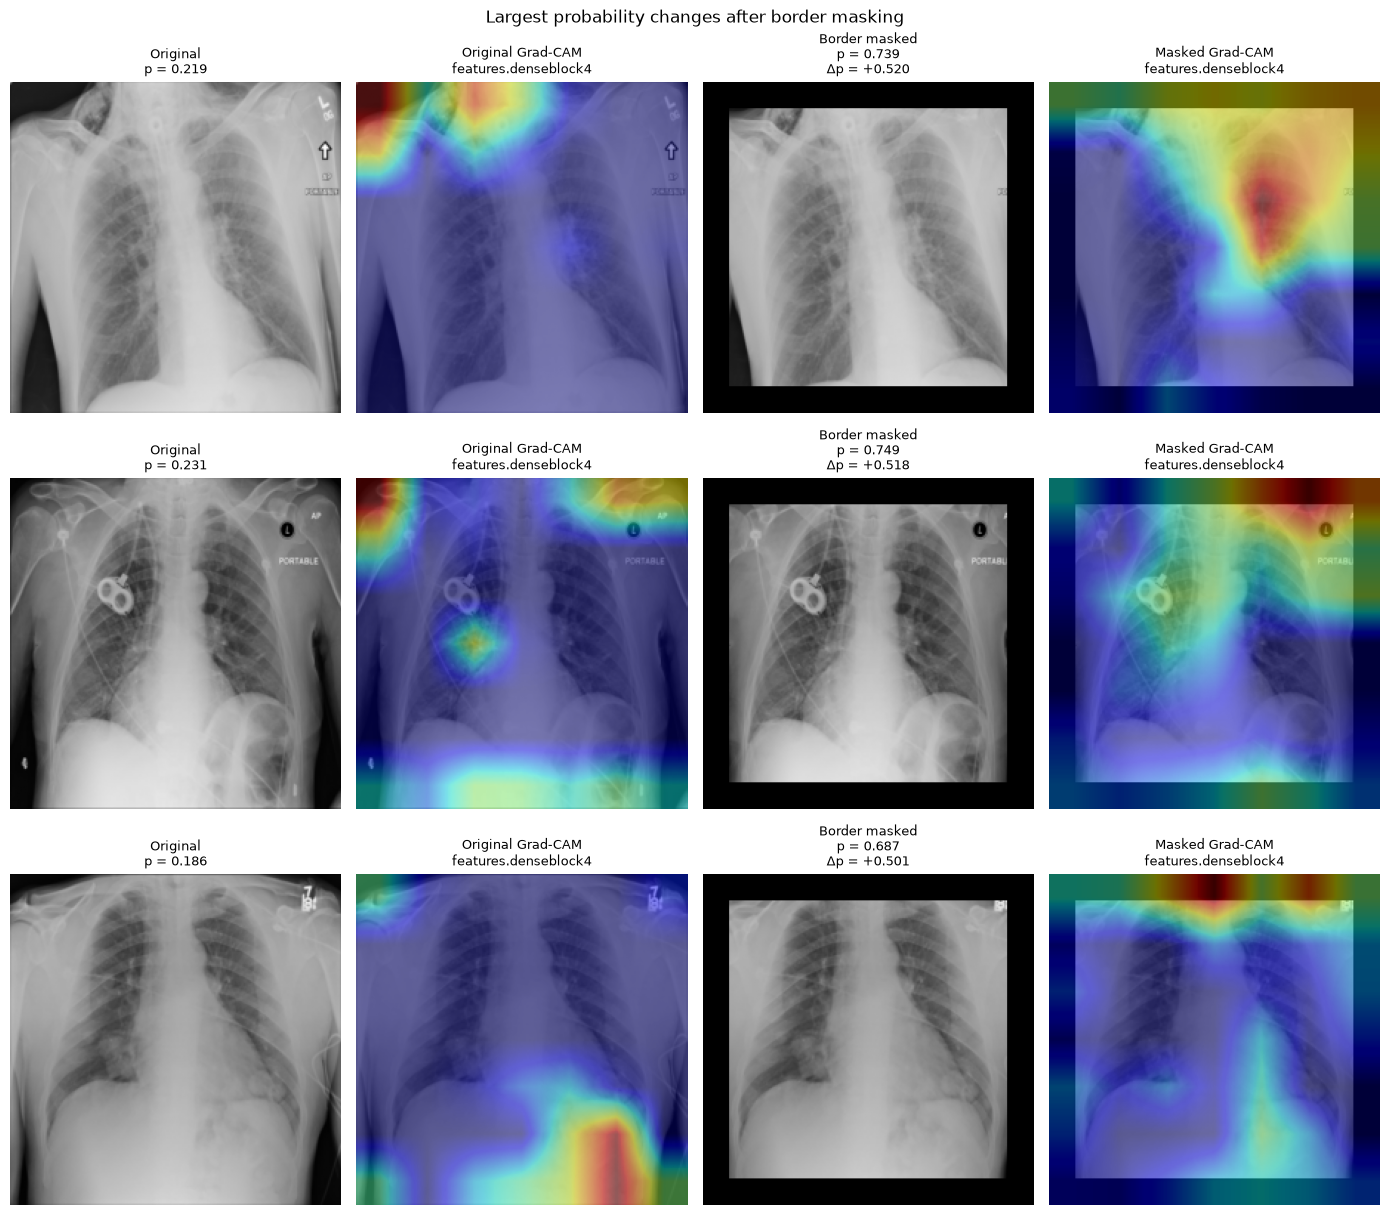

Three largest absolute border effects:
  1.2.276.0.7230010.3.1.4.8323329.9410.1517874342.916519: original = 0.2194, border-masked = 0.7389, Δp = +0.5195
  1.2.276.0.7230010.3.1.4.8323329.13526.1517874373.143153: original = 0.2314, border-masked = 0.7494, Δp = +0.5180
  1.2.276.0.7230010.3.1.4.8323329.23800.1517874450.4572: original = 0.1859, border-masked = 0.6868, Δp = +0.5009


In [47]:
# Bonus Question 2 - Part 3 (Grad-CAM before and after border masking)

largest_cases = shortcut_results.loc[
    shortcut_results["border_delta"].abs().nlargest(3).index
]

fig, axes = plt.subplots(
    len(largest_cases),
    4,
    figsize=(14, 4.2 * len(largest_cases)),
)

for row_index, (_, result) in enumerate(largest_cases.iterrows()):
    uid = result["SOPInstanceUID"]

    frame_row = test_frame[
        test_frame["SOPInstanceUID"] == uid
    ]

    image_tensor = ChestXrayDataset(
        frame_row,
        path_by_uid,
        evaluation_transform,
    )[0][0]

    height, width = image_tensor.shape[-2:]
    border_mask, _ = make_masks(height, width)
    border_tensor = apply_mask(image_tensor, border_mask)

    original_heatmap, original_prob = grad_cam(
        headline["model"],
        image_tensor,
        gradcam_layer,
    )

    masked_heatmap, masked_prob = grad_cam(
        headline["model"],
        border_tensor,
        gradcam_layer,
    )

    original_image = denormalize(image_tensor)
    masked_image = denormalize(border_tensor)

    axes[row_index, 0].imshow(
        original_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 0].set_title(
        f"Original\np = {original_prob:.3f}",
        fontsize=9,
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(
        original_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 1].imshow(
        original_heatmap,
        cmap="jet",
        alpha=0.45,
    )
    axes[row_index, 1].set_title(
        f"Original Grad-CAM\n{GRADCAM_LAYER_NAME}",
        fontsize=9,
    )
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(
        masked_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 2].set_title(
        f"Border masked\np = {masked_prob:.3f}\n"
        f"Δp = {masked_prob - original_prob:+.3f}",
        fontsize=9,
    )
    axes[row_index, 2].axis("off")

    axes[row_index, 3].imshow(
        masked_image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row_index, 3].imshow(
        masked_heatmap,
        cmap="jet",
        alpha=0.45,
    )
    axes[row_index, 3].set_title(
        f"Masked Grad-CAM\n{GRADCAM_LAYER_NAME}",
        fontsize=9,
    )
    axes[row_index, 3].axis("off")

fig.suptitle(
    "Largest probability changes after border masking",
    fontsize=12,
)
fig.tight_layout()
plt.show()

print("Three largest absolute border effects:")

for _, result in largest_cases.iterrows():
    print(
        f"  {result['SOPInstanceUID']}: "
        f"original = {result['original_probability']:.4f}, "
        f"border-masked = {result['border_probability']:.4f}, "
        f"Δp = {result['border_delta']:+.4f}"
    )

### Bonus 2: Shortcut stress test with a control

The border mask and control mask removed almost exactly the same amount of each image: **29.56% and 29.57%**, respectively. The control mask was placed inside the expected lung fields. Across all 3,754 test examinations, the mean absolute change in predicted probability was 0.0919 for the border mask and 0.3045 for the control mask.

The equal-sized control is important because masking any large part of an image can change the model's prediction. Comparing two regions of almost identical size helps determine whether the effect is specifically associated with removing the border rather than simply removing a large amount of image information.

Overall, predictions were substantially more affected by the control mask than by the border mask. This does **not provide evidence that the model relies more strongly on border information than on information inside the lung field**.

However, border information was not irrelevant for every examination. The three largest border-mask effects changed predicted probability by approximately **+0.50 to +0.52**, and their Grad-CAM patterns also changed after masking.

These results do not rule out shortcut learning. They only show that border removal had a smaller overall effect than the equal-area control in this experiment. Some individual examinations still showed large changes after border masking.